In [1]:
import duckdb
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

con = duckdb.connect("../Data/processed/project.duckdb")

trades_with_trader_df = con.execute("SELECT * FROM trades_with_trader WHERE traderId IS NOT NULL").fetchdf()
rebuilt_account_summary = pd.read_csv("../Data/processed/rebuilt_account_summary.csv")


DATA : The data being used is essentially the masterdataset stored as a table in project.duckdb as trades_with traders. 

- We are treating email as a primary key. As in, an emailID means a unique trader. According to PDPA laws, we cannot keep the email, tele ID column and therefore we created a "traderID" column, which is a unique identifier made by hashing the emailID (creating a unique serial number by hashing the email). 
- We added a campaignID column also, which just points to which campaign a user was a part of. We added this to both trades and users dataset files
- Then we joined these two to create trades_with_trader, which includes all columns of trades + traderID. We did this by joining users and trades on the condition that the campaign ID and account ID both were same. (in a given campaign, the accountID will belong to one person only, even though across campaigns the accountID is recycled)

# Data quality checks

In [2]:
print("\nTotal trades:", len(trades_with_trader_df))
print("Distinct traders:", trades_with_trader_df["traderId"].nunique())
print("\nNulls per column:\n", trades_with_trader_df.isna().sum())
print("\nDuplicate rows:", trades_with_trader_df.duplicated().sum())



Total trades: 46376
Distinct traders: 3550

Nulls per column:
 accountId            0
closeTradeId         0
positionId           0
closeOrderId         0
openOrderId          0
durationSec          0
openDateTime         0
closeDateTime        0
profit               0
reverseProfit        0
netProfit            0
commission           0
amount               0
openPrice            0
closePrice           0
slPrice          24546
tpPrice          20886
side                 0
userGroupId          0
filename             0
campaignId           0
has_SL               0
has_TP               0
traderId             0
dtype: int64

Duplicate rows: 0


In [3]:
#Range sanity check
print(trades_with_trader_df[["durationSec", "amount", "netProfit"]].describe())

        durationSec        amount     netProfit
count  46376.000000  46376.000000  46376.000000
mean    1413.167177      0.183879     -6.662067
std     3925.868104      0.144554    106.069356
min        0.000000      0.010000   -944.100000
25%       78.000000      0.090000    -51.700000
50%      272.000000      0.120000     -0.640000
75%      995.000000      0.250000     45.400000
max    79210.000000      0.630000    680.640000


Nothing here looks broken: it's confirming the data is usable before moving on to the actual hypothesis tests.

# Trader level profiling

In [4]:
trades_per_trader = trades_with_trader_df.groupby("traderId").size()
print("\nTrades per trader — mean:", round(trades_per_trader.mean(), 1),
      "median:", trades_per_trader.median(), "std:", round(trades_per_trader.std(), 1))

campaigns_per_trader = trades_with_trader_df.groupby("traderId")["campaignId"].nunique()
print("\nTraders in >1 campaign:", (campaigns_per_trader > 1).sum(), "of", len(campaigns_per_trader))

print("\nWinner/loser split:", rebuilt_account_summary["outcome"].value_counts().to_dict())



Trades per trader — mean: 13.1 median: 5.0 std: 26.7

Traders in >1 campaign: 1313 of 3550

Winner/loser split: {'loser': 2211, 'winner': 1339}


Median is only 5 — the typical trader made just 5 trades.

Mean is 13.1 — more than double the median.

Std is 26.7 — larger than the mean.

When mean > median and std > mean like this, it means a small number of very active traders (hundreds of trades each, pulling the average way up) are dragging the mean far above what a typical trader actually did. So "13.1 trades on average" is misleading as a description of a normal trader — **5 trades (the median) is a much better representation of typical behavior**, and the high std is telling you there's a long tail of a few outlier traders trading way more than everyone else.

Approximately 37% of traders participated in more than 1 campaign

IMP : Winners = positive net profit ; Losers = negative net profit

# EDA

In [5]:
#Test 1: Median holding time, winner vs loser
hold_by_trader = trades_with_trader_df.groupby("traderId")["durationSec"].median().reset_index(name="median_hold")
rebuilt_account_summary = rebuilt_account_summary.merge(hold_by_trader, on="traderId", how="left")
w = rebuilt_account_summary[rebuilt_account_summary["outcome"]=="winner"]["median_hold"].dropna()
l = rebuilt_account_summary[rebuilt_account_summary["outcome"]=="loser"]["median_hold"].dropna()
u1, p1 = stats.mannwhitneyu(w, l)
print(f"\n[1] Holding time — winner median: {w.median():.1f}s, loser: {l.median():.1f}s, p={p1:.4f}")



[1] Holding time — winner median: 610.0s, loser: 480.0s, p=0.0009


The results are significant, winners hold longer

In [6]:
#Test 2: Commission vs directional loss

total_comm = trades_with_trader_df["commission"].sum()
total_dir = trades_with_trader_df["profit"].sum()
print(f"[2] Commission: {total_comm:.2f}, Directional: {total_dir:.2f}, Ratio: {abs(total_comm/total_dir):.1f}x")

[2] Commission: -298472.87, Directional: -10487.16, Ratio: 28.5x


In [7]:
#Test 3: No-SL 50% threshold split

nosl_pct = trades_with_trader_df.groupby("traderId")["has_SL"].apply(lambda x: 100*(~x).mean()).reset_index(name="no_sl_pct_check")
rebuilt_account_summary = rebuilt_account_summary.merge(nosl_pct, on="traderId", how="left")
high = rebuilt_account_summary[rebuilt_account_summary["no_sl_pct_check"] >= 50]["total_netProfit"]
low = rebuilt_account_summary[rebuilt_account_summary["no_sl_pct_check"] < 50]["total_netProfit"]
t3, p3 = stats.ttest_ind(high, low, equal_var=False)
print(f"[3] No-SL split — high avg profit: {high.mean():.2f}, low: {low.mean():.2f}, p={p3:.4f}")

[3] No-SL split — high avg profit: -94.78, low: -75.95, p=0.1716


The results are not significant

In [8]:
#Test 4: Position size after loss vs after win

def get_after_loss_win_sizes(df, id_col):
    df = df.sort_values([id_col, "openDateTime"]).copy()
    df["prev_netProfit"] = df.groupby(id_col)["netProfit"].shift(1)
    df["prev_outcome"] = df["prev_netProfit"].apply(lambda x: "after_loss" if x < 0 else ("after_win" if x >= 0 else None))
    sizes = df.groupby([id_col, "prev_outcome"])["amount"].mean().unstack()
    sizes.columns = ["after_loss", "after_win"]
    return sizes.dropna()

sizes = get_after_loss_win_sizes(trades_with_trader_df, "traderId")
w4, p4 = stats.wilcoxon(sizes["after_loss"], sizes["after_win"])
print(f"[4] Size after loss: {sizes['after_loss'].median():.3f}, after win: {sizes['after_win'].median():.3f}, p={p4:.4f} (n={len(sizes)})")


[4] Size after loss: 0.159, after win: 0.150, p=0.0033 (n=2043)


The results are significant but we must tread lighty here because when this test was run on the masterdataset as accountID as the unique identifier, the results were actually the opposite of this. 

Prisha's take on this: We should trust this traderId-based result over the earlier accountId-based one, since accountId recycling across campaigns could wrongly merge/split traders' sequences and corrupt the after_loss/after_win pairing.

In [9]:
#Test 5: Max drawdown, winner vs loser

def fast_max_drawdown(df, id_col):
    df = df.sort_values([id_col, "openDateTime"]).copy()
    df["equity"] = df.groupby(id_col)["netProfit"].cumsum()
    df["running_max"] = df.groupby(id_col)["equity"].cummax()
    df["drawdown"] = df["equity"] - df["running_max"]
    return df.groupby(id_col)["drawdown"].min().reset_index(name="max_drawdown")

dd = fast_max_drawdown(trades_with_trader_df, "traderId")
rebuilt_account_summary = rebuilt_account_summary.merge(dd, on="traderId", how="left", suffixes=("", "_dup"))
w5 = rebuilt_account_summary[rebuilt_account_summary["outcome"]=="winner"]["max_drawdown"].dropna()
l5 = rebuilt_account_summary[rebuilt_account_summary["outcome"]=="loser"]["max_drawdown"].dropna()
u5, p5 = stats.mannwhitneyu(w5, l5)
print(f"[5] Max drawdown — winner: {w5.median():.1f}, loser: {l5.median():.1f}, p={p5:.4f}")



[5] Max drawdown — winner: -30.0, loser: -230.9, p=0.0000


Strong result, this helps seperate winners from losers 

-------------------------------------------------------------------------------------------------------------

# ADDITIONAL EDA ( WE CAN ADD CODE HERE AND CLEAN UP THIS PART LATER)

------------------------------------------------------------------------------------------------------------

# EDA FROM DEVANSHI IND

We want to check what the trader CROWD does in an hour and if it may predict what happens in the next hour

In [10]:
#all the trading details aggregated wrt whats happening by the hour
flow_by_hour = con.execute("""
    SELECT 
        campaignId,
        DATE_TRUNC('hour', openDateTime) AS hour_bucket,
        SUM(CASE WHEN side='BUY' THEN amount ELSE 0 END) AS buy_volume,
        SUM(CASE WHEN side='SELL' THEN amount ELSE 0 END) AS sell_volume,
        SUM(CASE WHEN side='BUY' THEN amount ELSE -amount END) AS net_flow,
        COUNT(*) AS n_trades,
        AVG(openPrice) AS avg_price,
        SUM(CASE WHEN NOT has_SL THEN 1 ELSE 0 END) AS n_no_sl,
        AVG(netProfit) AS avg_netProfit
    FROM trades_with_trader
    GROUP BY campaignId, hour_bucket
    ORDER BY campaignId, hour_bucket
""").fetchdf()

print(flow_by_hour.shape)
print(flow_by_hour.head(10))

(722, 9)
  campaignId               hour_bucket  buy_volume  sell_volume      net_flow  \
0         33 2026-02-24 08:00:00+08:00        0.00         0.04 -4.000000e-02   
1         33 2026-02-24 09:00:00+08:00        1.91         1.85  6.000000e-02   
2         33 2026-02-24 10:00:00+08:00        4.02         4.45 -4.300000e-01   
3         33 2026-02-24 11:00:00+08:00        1.39         2.58 -1.190000e+00   
4         33 2026-02-24 12:00:00+08:00        3.32         3.32  1.491862e-16   
5         33 2026-02-24 13:00:00+08:00        5.00         2.58  2.420000e+00   
6         33 2026-02-24 14:00:00+08:00        7.23         3.14  4.090000e+00   
7         33 2026-02-24 15:00:00+08:00       10.28         3.33  6.950000e+00   
8         33 2026-02-24 16:00:00+08:00        3.59         2.92  6.700000e-01   
9         33 2026-02-24 17:00:00+08:00        2.07         1.03  1.040000e+00   

   n_trades    avg_price  n_no_sl  avg_netProfit  
0         1  5229.600000      0.0     105.880000

In [11]:
# trying to check if the info we have about a CURRENT hour helps predict what may happen in the NEXT hour

#building the next hours price change column ( how much price moved after the current hour)
flow_by_hour = flow_by_hour.sort_values(["campaignId", "hour_bucket"]).reset_index(drop=True)

flow_by_hour["next_price"] = flow_by_hour.groupby("campaignId")["avg_price"].shift(-1)
flow_by_hour["price_change_next_hour"] = flow_by_hour["next_price"] - flow_by_hour["avg_price"]

#running the lagged correlation scan 
candidate_metrics = ["net_flow", "buy_volume", "sell_volume", "n_trades", "n_no_sl", "avg_netProfit"]

correlations = flow_by_hour[candidate_metrics + ["price_change_next_hour"]].corr()["price_change_next_hour"].drop("price_change_next_hour")

print(correlations.sort_values(key=abs, ascending=False))

net_flow         0.052417
buy_volume       0.043336
n_trades         0.035736
n_no_sl          0.019569
sell_volume      0.009554
avg_netProfit    0.006337
Name: price_change_next_hour, dtype: float64


this is a weak result

In [12]:
flow_by_hour["net_flow_pct"] = flow_by_hour["net_flow"] / (flow_by_hour["buy_volume"] + flow_by_hour["sell_volume"])
correlation_pct = flow_by_hour[["net_flow_pct", "price_change_next_hour"]].corr()
print(correlation_pct)

                        net_flow_pct  price_change_next_hour
net_flow_pct                 1.00000                 0.10943
price_change_next_hour       0.10943                 1.00000


In [13]:
for lag in [1, 2, 3, 4]:
    flow_by_hour[f"price_change_lag{lag}"] = (
        flow_by_hour.groupby("campaignId")["avg_price"].shift(-lag) - flow_by_hour["avg_price"]
    )
    corr = flow_by_hour["net_flow"].corr(flow_by_hour[f"price_change_lag{lag}"])
    print(f"Lag {lag} hour(s): correlation = {corr:.4f}")

Lag 1 hour(s): correlation = 0.0524
Lag 2 hour(s): correlation = 0.0241
Lag 3 hour(s): correlation = 0.0240
Lag 4 hour(s): correlation = 0.0103


this is obvious, the weak correlation keeps becoming less and less as time passes

In [14]:
extreme_buy = flow_by_hour[flow_by_hour["net_flow"] > flow_by_hour["net_flow"].quantile(0.9)]
extreme_sell = flow_by_hour[flow_by_hour["net_flow"] < flow_by_hour["net_flow"].quantile(0.1)]

print("After extreme net-buying hours, avg next-hour price change:", extreme_buy["price_change_next_hour"].mean())
print("After extreme net-selling hours, avg next-hour price change:", extreme_sell["price_change_next_hour"].mean())

After extreme net-buying hours, avg next-hour price change: 0.3639303870228143
After extreme net-selling hours, avg next-hour price change: -2.668097649834517


This may be a obvious result but gold prices moved a lot over 4.5 months(during all the campaigns) so we need to check if extreme buying predicts a move beyond what the general trend would already predict.Simplest version: detrend by looking at the price change relative to the campaign's own average movement that day, not the raw price change.

In [15]:
# subtract each campaign's own average hourly price change, to remove the trend
flow_by_hour["campaign_avg_change"] = flow_by_hour.groupby("campaignId")["price_change_next_hour"].transform("mean")
flow_by_hour["detrended_change"] = flow_by_hour["price_change_next_hour"] - flow_by_hour["campaign_avg_change"]

extreme_buy = flow_by_hour[flow_by_hour["net_flow_pct"] > flow_by_hour["net_flow_pct"].quantile(0.9)]
extreme_sell = flow_by_hour[flow_by_hour["net_flow_pct"] < flow_by_hour["net_flow_pct"].quantile(0.1)]

print("Extreme buy, detrended next-hour change:", extreme_buy["detrended_change"].mean())
print("Extreme sell, detrended next-hour change:", extreme_sell["detrended_change"].mean())

Extreme buy, detrended next-hour change: 3.6670206887557986
Extreme sell, detrended next-hour change: -2.550320908006554


In [16]:
flow_by_hour = flow_by_hour.sort_values(["campaignId", "hour_bucket"]).reset_index(drop=True)

behavior_cols = ["net_flow_pct", "n_trades", "n_no_sl", "avg_netProfit", "buy_volume", "sell_volume"]

for col in behavior_cols:
    flow_by_hour[f"next_{col}"] = flow_by_hour.groupby("campaignId")[col].shift(-1)

# also useful: no-SL as a RATE, not raw count, so it's comparable across busier/quieter hours
flow_by_hour["no_sl_rate"] = flow_by_hour["n_no_sl"] / flow_by_hour["n_trades"]
flow_by_hour["next_no_sl_rate"] = flow_by_hour.groupby("campaignId")["no_sl_rate"].shift(-1)

this_hour = ["net_flow_pct", "n_trades", "no_sl_rate", "avg_netProfit"]
next_hour = ["next_net_flow_pct", "next_n_trades", "next_no_sl_rate", "next_avg_netProfit"]

corr_matrix = flow_by_hour[this_hour + next_hour].corr().loc[this_hour, next_hour]
print(corr_matrix.round(3))



               next_net_flow_pct  next_n_trades  next_no_sl_rate  \
net_flow_pct               0.055         -0.021           -0.047   
n_trades                  -0.036          0.784            0.056   
no_sl_rate                 0.016          0.085            0.313   
avg_netProfit              0.015          0.070            0.127   

               next_avg_netProfit  
net_flow_pct                0.137  
n_trades                    0.032  
no_sl_rate                  0.009  
avg_netProfit               0.024  


1. this just shows that high number of trades are just followed by high number of trades in the next hour (0.763) 
2. but also that no sl is maybe followed by no sl in the next hour 

lets look at the no sl thing 

In [17]:
# among NO-SL trades only, look at the distribution of losses
no_sl_losses = trades_with_trader_df[
    (~trades_with_trader_df["has_SL"]) & (trades_with_trader_df["netProfit"] < 0)
]["netProfit"]

print(no_sl_losses.describe())
print("\nWhat % of no-SL losses are 'small/disciplined' (say, better than -50) vs 'catastrophic' (worse than -300)?")
print("Disciplined-ish:", (no_sl_losses > -50).mean())
print("Catastrophic:", (no_sl_losses < -300).mean())

count    11323.000000
mean       -91.286328
std        103.795039
min       -944.100000
25%       -135.600000
50%        -51.960000
75%        -14.105000
max         -0.010000
Name: netProfit, dtype: float64

What % of no-SL losses are 'small/disciplined' (say, better than -50) vs 'catastrophic' (worse than -300)?
Disciplined-ish: 0.48988783891194915
Catastrophic: 0.04936854190585534


In [18]:
catastrophic = trades_with_trader_df[
    (~trades_with_trader_df["has_SL"]) & (trades_with_trader_df["netProfit"] < -300)
]

disciplined = trades_with_trader_df[
    (~trades_with_trader_df["has_SL"]) & (trades_with_trader_df["netProfit"] < 0) & (trades_with_trader_df["netProfit"] > -50)
]

print("Catastrophic trades — median duration:", catastrophic["durationSec"].median(), 
      "median size:", catastrophic["amount"].median())
print("Disciplined trades — median duration:", disciplined["durationSec"].median(), 
      "median size:", disciplined["amount"].median())

Catastrophic trades — median duration: 1267.0 median size: 0.3
Disciplined trades — median duration: 63.0 median size: 0.1


In [19]:
no_sl_trades = trades_with_trader_df[~trades_with_trader_df["has_SL"]].copy()
no_sl_trades["is_catastrophic"] = no_sl_trades["netProfit"] < -300

# check: among trades that are STILL OPEN past 5 minutes (300 sec) with above-median size,
# what fraction eventually go catastrophic, vs trades that don't meet that criteria?
median_size = no_sl_trades["amount"].median()

no_sl_trades["flagged"] = (no_sl_trades["durationSec"] > 300) & (no_sl_trades["amount"] > median_size)

print(no_sl_trades.groupby("flagged")["is_catastrophic"].mean())
print(no_sl_trades["flagged"].value_counts())

flagged
False    0.015265
True     0.098732
Name: is_catastrophic, dtype: float64
flagged
False    22338
True      2208
Name: count, dtype: int64


In [20]:
catastrophic = trades_with_trader_df[
    (~trades_with_trader_df["has_SL"]) & (trades_with_trader_df["netProfit"] < -300)
]

disciplined = trades_with_trader_df[
    (~trades_with_trader_df["has_SL"]) & (trades_with_trader_df["netProfit"] < 0) & (trades_with_trader_df["netProfit"] > -50)
]

print("Catastrophic trades — avg reverseProfit:", catastrophic["reverseProfit"].mean())
print("Disciplined trades — avg reverseProfit:", disciplined["reverseProfit"].mean())

# also worth checking: reverseProfit specifically for the FLAGGED group vs non-flagged
print("\nFlagged trades — avg reverseProfit:", no_sl_trades[no_sl_trades["flagged"]]["reverseProfit"].mean())
print("Non-flagged trades — avg reverseProfit:", no_sl_trades[~no_sl_trades["flagged"]]["reverseProfit"].mean())

Catastrophic trades — avg reverseProfit: 380.3320035778176
Disciplined trades — avg reverseProfit: 10.441956913647017

Flagged trades — avg reverseProfit: 23.03688405797101
Non-flagged trades — avg reverseProfit: -1.1453796221685022


# EDA FROM PRISHA

### Viewing project.duckdb, trades_with_trader, trades_campaign_features directly

In [21]:
# project.duckdb: list tables and preview one
print(con.execute("SHOW TABLES").fetchdf())
con.execute("SELECT * FROM trades_with_trader LIMIT 5").fetchdf()

                       name
0                    trades
1  trades_campaign_features
2        trades_with_trader
3                     users


,accountId,closeTradeId,positionId,closeOrderId,openOrderId,durationSec,openDateTime,closeDateTime,profit,reverseProfit,...,closePrice,slPrice,tpPrice,side,userGroupId,filename,campaignId,has_SL,has_TP,traderId
0,D#1702379,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,19,2026-02-24 09:02:19+08:00,2026-02-24 09:02:38+08:00,0.47,-0.54,...,5206.14,NaN,NaN,BUY,1583663,data/raw/user_trades/Campaign 33 Data 24 Feb 2...,33,False,False,9610a0dfe436
1,D#1645651,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,29,2026-02-24 09:02:15+08:00,2026-02-24 09:02:44+08:00,2.24,-2.31,...,5207.23,NaN,NaN,SELL,1583663,data/raw/user_trades/Campaign 33 Data 24 Feb 2...,33,False,False,6592ab90514d
2,D#1670922,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,38,2026-02-24 09:07:03+08:00,2026-02-24 09:07:41+08:00,1.00,-1.07,...,5200.16,NaN,NaN,SELL,1583663,data/raw/user_trades/Campaign 33 Data 24 Feb 2...,33,False,False,2baef295c655
3,D#1702617,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,208,2026-02-24 09:06:23+08:00,2026-02-24 09:09:51+08:00,5.52,-5.73,...,5206.58,NaN,NaN,BUY,1583663,data/raw/user_trades/Campaign 33 Data 24 Feb 2...,33,False,False,45473583265f
4,D#1670952,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,109,2026-02-24 09:09:51+08:00,2026-02-24 09:11:40+08:00,61.60,-62.30,...,5200.67,NaN,NaN,SELL,1583663,data/raw/user_trades/Campaign 33 Data 24 Feb 2...,33,False,False,d3d1abf7f5c0


In [22]:
# project.duckdb: list tables and preview one
print(con.execute("SHOW TABLES").fetchdf())
con.execute("SELECT * FROM trades_campaign_features LIMIT 5").fetchdf()

                       name
0                    trades
1  trades_campaign_features
2        trades_with_trader
3                     users


,accountId,closeTradeId,positionId,closeOrderId,openOrderId,durationSec,openDateTime,closeDateTime,profit,reverseProfit,...,campaignId,has_SL,has_TP,traderId,trade_seq_in_campaign,equity,running_peak,drawdown,streak,reentry_gap_sec
0,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,36,2026-03-03 09:55:53+08:00,2026-03-03 09:56:29+08:00,20.80,-21.50,...,34,False,False,00094c908d31,1.0,5017.30,5017.30,0.00,1.0,NaN
1,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,240,2026-03-03 09:59:46+08:00,2026-03-03 10:03:46+08:00,32.70,-33.05,...,34,False,True,00094c908d31,2.0,5048.24,5048.24,0.00,2.0,197.0
2,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,1978,2026-03-03 13:34:39+08:00,2026-03-03 14:07:37+08:00,-189.40,189.05,...,34,True,True,00094c908d31,3.0,4857.08,5048.24,-191.16,-1.0,12653.0
3,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,16,2026-03-03 14:11:27+08:00,2026-03-03 14:11:43+08:00,3.90,-4.25,...,34,False,False,00094c908d31,4.0,4859.22,5048.24,-189.02,1.0,230.0
4,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,5,2026-03-03 14:11:54+08:00,2026-03-03 14:11:59+08:00,5.25,-5.60,...,34,False,False,00094c908d31,5.0,4862.71,5048.24,-185.53,2.0,11.0


### Campaign-aware features (viewing trades_campaign_features)

Each campaign starts from a fresh $5000 account, so equity/peak/streak/re-entry gap need to reset at each (traderId, campaignId) boundary rather than carrying over across a trader's whole history. 
This section loads a new table built by `Scripts/latest_master_ds.py`, without changing anything in the sections above.

New columns, computed per trader per campaign, in time order:
- `trade_seq_in_campaign` — trade number within that campaign, restarting at 1
- `equity` — running balance, starting at $5000 each campaign
- `running_peak` — highest equity reached so far that campaign
- `drawdown` — equity minus running_peak (always ≤ 0)
- `streak` — signed win/loss streak (+2 = 2 wins in a row, -3 = 3 losses in a row), resets each campaign
- `reentry_gap_sec` — seconds since this trader's previous trade closed, within the same campaign only (NULL on each campaign's first trade)

In [23]:
trades_campaign_features_df = con.execute(
    "SELECT * FROM trades_campaign_features WHERE traderId IS NOT NULL"
).fetchdf()

print("Rows:", len(trades_campaign_features_df))
trades_campaign_features_df[
    ["traderId", "campaignId", "trade_seq_in_campaign", "netProfit",
     "equity", "running_peak", "drawdown", "streak", "reentry_gap_sec"]
].head(10)

Rows: 46376


,traderId,campaignId,trade_seq_in_campaign,netProfit,equity,running_peak,drawdown,streak,reentry_gap_sec
0,00094c908d31,34,1.0,17.30,5017.30,5017.30,0.00,1.0,NaN
1,00094c908d31,34,2.0,30.94,5048.24,5048.24,0.00,2.0,197.0
2,00094c908d31,34,3.0,-191.16,4857.08,5048.24,-191.16,-1.0,12653.0
3,00094c908d31,34,4.0,2.14,4859.22,5048.24,-189.02,1.0,230.0
4,00094c908d31,34,5.0,3.49,4862.71,5048.24,-185.53,2.0,11.0
5,00094c908d31,34,6.0,-47.96,4814.75,5048.24,-233.49,-1.0,5.0
6,00094c908d31,35,1.0,23.54,5023.54,5023.54,0.00,1.0,NaN
7,00094c908d31,35,2.0,3.49,5027.03,5027.03,0.00,2.0,1091.0
8,00094c908d31,35,3.0,-247.50,4779.53,5027.03,-247.50,-1.0,1438.0
9,00094c908d31,36,1.0,46.60,5046.60,5046.60,0.00,1.0,NaN


Assumption used below: the 4% max-drawdown rule is treated as **static** (equity < $4,800 at any point in a campaign) rather than trailing from the trader's own peak.


In [24]:
# Test 6: Re-entry Haste Index - faster re-entry after a loss than after a win, tested against campaign-correct max drawdown

tcf = trades_campaign_features_df.copy()
tcf["prev_netProfit"] = tcf.groupby(["traderId", "campaignId"])["netProfit"].shift(1)
tcf["prev_outcome"] = tcf["prev_netProfit"].apply(
    lambda x: "after_loss" if x < 0 else ("after_win" if x >= 0 else None)
)

gap_by_trader = (
    tcf.dropna(subset=["reentry_gap_sec", "prev_outcome"])
    .groupby(["traderId", "prev_outcome"])["reentry_gap_sec"]
    .median()
    .unstack()
    .dropna(subset=["after_loss", "after_win"])
)
gap_by_trader["haste_index"] = gap_by_trader["after_loss"] / gap_by_trader["after_win"]

max_dd_campaign_aware = tcf.groupby("traderId")["drawdown"].min().rename("max_drawdown_campaign_aware")
haste_df = gap_by_trader.join(max_dd_campaign_aware).dropna()

haste_group = haste_df[haste_df["haste_index"] < 1]["max_drawdown_campaign_aware"]
not_haste_group = haste_df[haste_df["haste_index"] >= 1]["max_drawdown_campaign_aware"]

u_haste, p_haste = stats.mannwhitneyu(haste_group, not_haste_group)
print(f"Re-entry Haste Index - haste traders (n={len(haste_group)}) median max drawdown: {haste_group.median():.1f}, "
      f"non-haste (n={len(not_haste_group)}) median: {not_haste_group.median():.1f}, p={p_haste:.4f}")


Re-entry Haste Index - haste traders (n=1351) median max drawdown: -270.4, non-haste (n=595) median: -210.4, p=0.0000


Strong: Confirms the Stage 1 re-entry haste lead: traders who re-enter faster after a loss than after a win (n=1351) show ~29% deeper max drawdown than non-haste traders (n=595), p<0.0001. Strong candidate for a post-loss cool-off intervention.


In [25]:
# Test 7: Tilt Score - does bet size escalate the longer a losing streak runs?
# this is the more specific version of Test 4, looking at longer streaks instead of the previous trade only

import numpy as np

tilt_source = trades_campaign_features_df[trades_campaign_features_df["streak"] < 0].copy()
tilt_source["loss_streak_len"] = tilt_source["streak"].abs().clip(upper=4)  # cap at 4+

def trader_tilt_slope(group):
    if group["loss_streak_len"].nunique() < 3:
        return np.nan
    return np.polyfit(group["loss_streak_len"].values, group["amount"].values, 1)[0]

tilt_slopes = tilt_source.groupby("traderId").apply(trader_tilt_slope).dropna().rename("tilt_slope")

pct_escalating = (tilt_slopes > 0).mean() * 100
w_tilt, p_tilt = stats.wilcoxon(tilt_slopes)
print(f"Tilt Score — {len(tilt_slopes)} traders scored. {pct_escalating:.1f}% show a positive slope "
      f"(bigger bets deeper into a losing streak). Population slope vs. zero: p={p_tilt:.4f}")


Tilt Score — 1173 traders scored. 64.4% show a positive slope (bigger bets deeper into a losing streak). Population slope vs. zero: p=0.0000


Very strong: of 1173 traders with enough losing-streak depth to score (1, 2, 3), 61.6% escalate bet size the longer the streak runs (p<0.0001).

In [26]:
# Test 8: Warning-Response Simulation Score - % of trades placed after equity first crosses the static 4% drawdown line ($4,800), winners vs losers

STATIC_DD_THRESHOLD = 5000 * (1 - 0.04)  # $4800

tcf_sorted = trades_campaign_features_df.sort_values(["traderId", "campaignId", "trade_seq_in_campaign"]).copy()
tcf_sorted["breached"] = tcf_sorted["equity"] < STATIC_DD_THRESHOLD
tcf_sorted["ever_breached_so_far"] = tcf_sorted.groupby(["traderId", "campaignId"])["breached"].cummax()

warning_response = (
    tcf_sorted.groupby("traderId")["ever_breached_so_far"].mean() * 100
).rename("warning_response_pct").reset_index()

warning_df = warning_response.merge(
    rebuilt_account_summary[["traderId", "outcome"]], on="traderId", how="inner"
)

w_group = warning_df[warning_df["outcome"] == "winner"]["warning_response_pct"]
l_group = warning_df[warning_df["outcome"] == "loser"]["warning_response_pct"]
u_wr, p_wr = stats.mannwhitneyu(w_group, l_group)
print(f"Warning-Response Score — winner median: {w_group.median():.1f}% of trades post-breach, "
      f"loser median: {l_group.median():.1f}%, p={p_wr:.4f}")


Warning-Response Score — winner median: 0.0% of trades post-breach, loser median: 11.1%, p=0.0000


Not sure about the strength of this hypothesis but it shows: a simple $4,800 balance alarm would almost only trigger for eventual losers (11.1% of their trades happen after crossing it, vs 0.0% for the typical winner, p<0.0001) (and with real time left to intervene, not just after the fact.)


In [27]:
# Test 9: Overconfidence Index - bet size after 2+ consecutive wins vs. trader's own baseline

trade_counts = trades_with_trader_df.groupby("traderId").size()
eligible_traders = trade_counts[trade_counts >= 10].index

baseline_amount = trades_campaign_features_df.groupby("traderId")["amount"].median()
after_win_streak_amount = (
    trades_campaign_features_df[trades_campaign_features_df["streak"] >= 2]
    .groupby("traderId")["amount"].median()
)

overconfidence = (after_win_streak_amount / baseline_amount).dropna()
overconfidence = overconfidence[overconfidence.index.isin(eligible_traders)]

w_oc, p_oc = stats.wilcoxon(overconfidence - 1)
print(f"Overconfidence Index — median ratio: {overconfidence.median():.3f} "
      f"(n={len(overconfidence)} traders), vs. baseline of 1.0: p={p_oc:.4f}")


Overconfidence Index — median ratio: 1.000 (n=995 traders), vs. baseline of 1.0: p=0.0003


weak result: most traders don't change their sizing behavior after a win streak at all, but among the minority who do adjust, the adjustment leans toward overconfidence

In [28]:
# Test 10: Friction-to-Edge Ratio per trader - basically a per-trader version of Test 2 instead of the overall ratio

per_trader_totals = trades_with_trader_df.groupby("traderId").agg(
    total_commission=("commission", "sum"),
    total_profit=("profit", "sum"),
    n_trades=("netProfit", "size"),
)
per_trader_totals = per_trader_totals[
    (per_trader_totals["n_trades"] >= 10) & (per_trader_totals["total_profit"] != 0)
]
per_trader_totals["friction_to_edge"] = (
    per_trader_totals["total_commission"].abs() / per_trader_totals["total_profit"].abs()
)

print(f"Friction-to-Edge Ratio per trader (n={len(per_trader_totals)} traders with ≥10 trades)")
print(per_trader_totals["friction_to_edge"].describe())


Friction-to-Edge Ratio per trader (n=1077 traders with ≥10 trades)
count    1077.000000
mean        1.960355
std        10.561593
min         0.023112
25%         0.197339
50%         0.401528
75%         0.969887
max       273.984000
Name: friction_to_edge, dtype: float64


Interesting finding but not sure of relevance: Friction isn't a universal 28.5x tax - the median trader pays only 0.4x their own directional P&L in commission, but a small tail runs up to 273.98x. Friction drag is concentrated in a niche, not spread evenly — a fee-awareness nudge should target that tail, not broadcast to everyone.


# EDA FROM AANYA [METHODS 2 and 3 AS COVERED IN THE DOC]

## Method 2 : One variable sweeps 

In [29]:
print(trades_campaign_features_df.columns.tolist())
trades_campaign_features_df.head()

['accountId', 'closeTradeId', 'positionId', 'closeOrderId', 'openOrderId', 'durationSec', 'openDateTime', 'closeDateTime', 'profit', 'reverseProfit', 'netProfit', 'commission', 'amount', 'openPrice', 'closePrice', 'slPrice', 'tpPrice', 'side', 'userGroupId', 'filename', 'campaignId', 'has_SL', 'has_TP', 'traderId', 'trade_seq_in_campaign', 'equity', 'running_peak', 'drawdown', 'streak', 'reentry_gap_sec']


,accountId,closeTradeId,positionId,closeOrderId,openOrderId,durationSec,openDateTime,closeDateTime,profit,reverseProfit,...,campaignId,has_SL,has_TP,traderId,trade_seq_in_campaign,equity,running_peak,drawdown,streak,reentry_gap_sec
0,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,36,2026-03-03 09:55:53+08:00,2026-03-03 09:56:29+08:00,20.80,-21.50,...,34,False,False,00094c908d31,1.0,5017.30,5017.30,0.00,1.0,NaN
1,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,240,2026-03-03 09:59:46+08:00,2026-03-03 10:03:46+08:00,32.70,-33.05,...,34,False,True,00094c908d31,2.0,5048.24,5048.24,0.00,2.0,197.0
2,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,1978,2026-03-03 13:34:39+08:00,2026-03-03 14:07:37+08:00,-189.40,189.05,...,34,True,True,00094c908d31,3.0,4857.08,5048.24,-191.16,-1.0,12653.0
3,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,16,2026-03-03 14:11:27+08:00,2026-03-03 14:11:43+08:00,3.90,-4.25,...,34,False,False,00094c908d31,4.0,4859.22,5048.24,-189.02,1.0,230.0
4,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,5,2026-03-03 14:11:54+08:00,2026-03-03 14:11:59+08:00,5.25,-5.60,...,34,False,False,00094c908d31,5.0,4862.71,5048.24,-185.53,2.0,11.0


In [30]:
import numpy as np


def prepare(df):
    out = df.copy()

    # rev_per_lot — guard against amount == 0
    safe_amount = out["amount"].where(out["amount"] != 0, np.nan)
    out["rev_per_lot"] = out["reverseProfit"] / safe_amount

    # streak split
    out["loss_streak"] = (-out["streak"]).clip(lower=0)
    out["win_streak"] = out["streak"].clip(lower=0)

    # drawdown as % of the $200 (4% of $5000) limit
    out["dd_pct_of_limit"] = (-out["drawdown"]) / 200

    # size vs trader's own expanding avg amount, prior trades only, per (traderId, campaignId)
    ordered = out.sort_values(["traderId", "campaignId", "trade_seq_in_campaign"])
    prior_avg = ordered.groupby(["traderId", "campaignId"])["amount"].transform(
        lambda s: s.shift(1).expanding().mean()
    )
    safe_prior_avg = prior_avg.where(prior_avg != 0, np.nan)
    out["size_vs_running_avg"] = (ordered["amount"] / safe_prior_avg).reindex(out.index)

    # hour of day
    out["hour_of_day"] = pd.to_datetime(out["openDateTime"], errors="coerce").dt.hour

    new_cols = [
        "rev_per_lot", "loss_streak", "win_streak",
        "dd_pct_of_limit", "size_vs_running_avg", "hour_of_day",
    ]
    print("Non-null coverage for derived columns:")
    for col in new_cols:
        print(f"  {col}: {out[col].notna().sum()} / {len(out)}")

    return out


prepared_df = prepare(trades_campaign_features_df)
prepared_df.head()

Non-null coverage for derived columns:
  rev_per_lot: 46376 / 46376
  loss_streak: 46376 / 46376
  win_streak: 46376 / 46376
  dd_pct_of_limit: 46376 / 46376
  size_vs_running_avg: 38248 / 46376
  hour_of_day: 46376 / 46376


,accountId,closeTradeId,positionId,closeOrderId,openOrderId,durationSec,openDateTime,closeDateTime,profit,reverseProfit,...,running_peak,drawdown,streak,reentry_gap_sec,rev_per_lot,loss_streak,win_streak,dd_pct_of_limit,size_vs_running_avg,hour_of_day
0,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,36,2026-03-03 09:55:53+08:00,2026-03-03 09:56:29+08:00,20.80,-21.50,...,5017.30,0.00,1.0,NaN,-215.0,0.0,1.0,-0.00000,NaN,9
1,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,240,2026-03-03 09:59:46+08:00,2026-03-03 10:03:46+08:00,32.70,-33.05,...,5048.24,0.00,2.0,197.0,-661.0,0.0,2.0,-0.00000,0.500000,9
2,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,1978,2026-03-03 13:34:39+08:00,2026-03-03 14:07:37+08:00,-189.40,189.05,...,5048.24,-191.16,-1.0,12653.0,3781.0,1.0,0.0,0.95580,0.666667,13
3,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,16,2026-03-03 14:11:27+08:00,2026-03-03 14:11:43+08:00,3.90,-4.25,...,5048.24,-189.02,1.0,230.0,-85.0,0.0,1.0,0.94510,0.750000,14
4,D#1702589,7.349875e+18,7.349875e+18,7.349875e+18,7.349875e+18,5,2026-03-03 14:11:54+08:00,2026-03-03 14:11:59+08:00,5.25,-5.60,...,5048.24,-185.53,2.0,11.0,-112.0,0.0,2.0,0.92765,0.800000,14


In [31]:
def baseline_and_split(prepared_df):
    # 1. Baseline: reverse everything blindly
    baseline_mean_rev_per_lot = prepared_df["rev_per_lot"].mean()
    baseline_sum_reverseProfit = prepared_df["reverseProfit"].sum()
    baseline_n_trades = len(prepared_df)

    print("BASELINE (reverse everything blindly):")
    print(f"  mean rev_per_lot: {baseline_mean_rev_per_lot:.4f}")
    print(f"  sum reverseProfit: {baseline_sum_reverseProfit:.2f}")
    print(f"  total trades: {baseline_n_trades}")

    # 2. Walk-forward split by campaign, ordered by campaignId
    campaign_order = sorted(prepared_df["campaignId"].unique(), key=int)
    n_campaigns = len(campaign_order)
    n_discovery = round(n_campaigns * 0.7)

    discovery_campaigns = campaign_order[:n_discovery]
    confirmation_campaigns = campaign_order[n_discovery:]

    discovery_df = prepared_df[prepared_df["campaignId"].isin(discovery_campaigns)].copy()
    confirmation_df = prepared_df[prepared_df["campaignId"].isin(confirmation_campaigns)].copy()

    overlap = set(discovery_campaigns) & set(confirmation_campaigns)

    print()
    print("WALK-FORWARD SPLIT (by campaign, ordered by campaignId):")
    print(f"  discovery:    {len(discovery_campaigns)} campaigns, {len(discovery_df)} trades")
    print(f"  confirmation: {len(confirmation_campaigns)} campaigns, {len(confirmation_df)} trades")
    print(f"  campaignId overlap between sets: {len(overlap)} (must be 0) -> {'OK' if len(overlap) == 0 else 'FAILED'}")

    return discovery_df, confirmation_df


discovery_df, confirmation_df = baseline_and_split(prepared_df)

BASELINE (reverse everything blindly):
  mean rev_per_lot: -5.2446
  sum reverseProfit: -49111.46
  total trades: 46376

WALK-FORWARD SPLIT (by campaign, ordered by campaignId):
  discovery:    24 campaigns, 30549 trades
  confirmation: 10 campaigns, 15827 trades
  campaignId overlap between sets: 0 (must be 0) -> OK


In [32]:
def sweep(df, var, bins, baseline_rev_per_lot, labels=None):
    n_missing = df[var].isna().sum()
    work = df.dropna(subset=[var]).copy()
    if n_missing:
        print(f"Dropped {n_missing} rows with NaN in '{var}'")

    # bins=None -> var is already categorical/boolean, use its values directly as buckets
    if bins is None:
        work["_bucket"] = work[var]
    else:
        work["_bucket"] = pd.cut(work[var], bins=bins, labels=labels)

    rows = []
    for bucket, g in work.groupby("_bucket", observed=True):
        n = len(g)
        mean_rpl = g["rev_per_lot"].mean()
        if n >= 2 and g["rev_per_lot"].std(ddof=1) > 0:
            sem = g["rev_per_lot"].std(ddof=1) / np.sqrt(n)
            t_crit = stats.t.ppf(0.975, df=n - 1)
            ci_low, ci_high = mean_rpl - t_crit * sem, mean_rpl + t_crit * sem
        else:
            ci_low, ci_high = np.nan, np.nan
        rows.append({
            "bucket": bucket,
            "n": n,
            "mean_rev_per_lot": mean_rpl,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "sum_reverseProfit": g["reverseProfit"].sum(),
            "median_amount": g["amount"].median(),
        })

    result = pd.DataFrame(rows)
    try:
        result = result.sort_values("bucket").reset_index(drop=True)
    except TypeError:
        result = result.reset_index(drop=True)

    # --- bar chart ---
    x_labels = result["bucket"].astype(str)
    yerr_low = result["mean_rev_per_lot"] - result["ci_low"]
    yerr_high = result["ci_high"] - result["mean_rev_per_lot"]
    colors = np.where(result["ci_low"] > 0, "green", "grey")

    fig, ax = plt.subplots(figsize=(max(6, len(result) * 1.2), 5))
    bars = ax.bar(
        x_labels, result["mean_rev_per_lot"],
        yerr=[yerr_low.fillna(0), yerr_high.fillna(0)],
        capsize=4, color=colors,
    )
    ax.axhline(baseline_rev_per_lot, linestyle="--", color="black", linewidth=1,
               label=f"baseline = {baseline_rev_per_lot:.4f}")
    for bar, n in zip(bars, result["n"]):
        ax.annotate(f"n={n}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)
    ax.set_xlabel(var)
    ax.set_ylabel("mean rev_per_lot")
    ax.set_title(f"rev_per_lot by {var}")
    ax.legend()
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # --- flip point ---
    flip = result[result["mean_rev_per_lot"] > 0]
    if len(flip):
        print(f"Flip point: lowest bucket with mean rev_per_lot > 0 is '{flip.iloc[0]['bucket']}'")
    else:
        print("Flip point: no flip")

    return result

Discovery baseline mean rev_per_lot: -9.0465


loss_streak


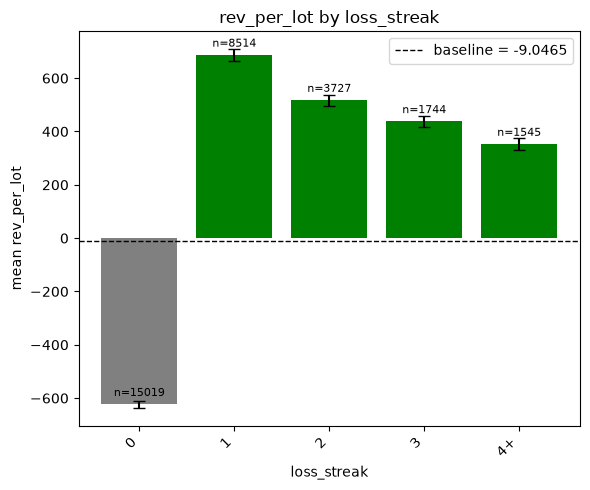

Flip point: lowest bucket with mean rev_per_lot > 0 is '1'

reentry_gap_sec
Dropped 5445 rows with NaN in 'reentry_gap_sec'


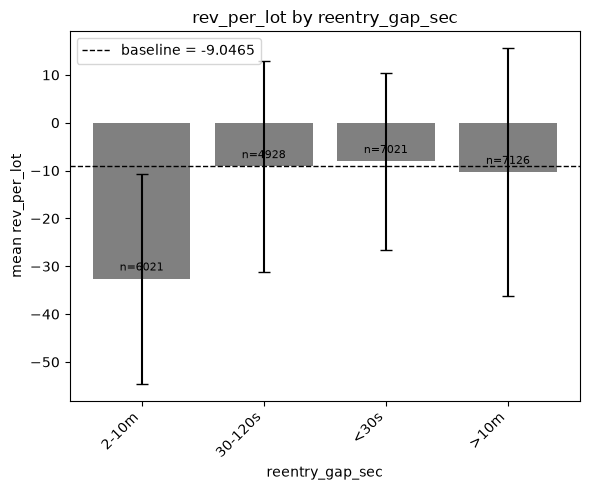

Flip point: no flip

dd_pct_of_limit


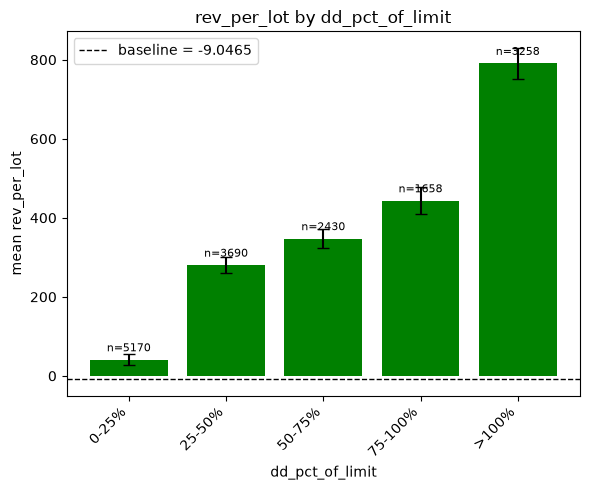

Flip point: lowest bucket with mean rev_per_lot > 0 is '0-25%'

size_vs_running_avg
Dropped 5445 rows with NaN in 'size_vs_running_avg'


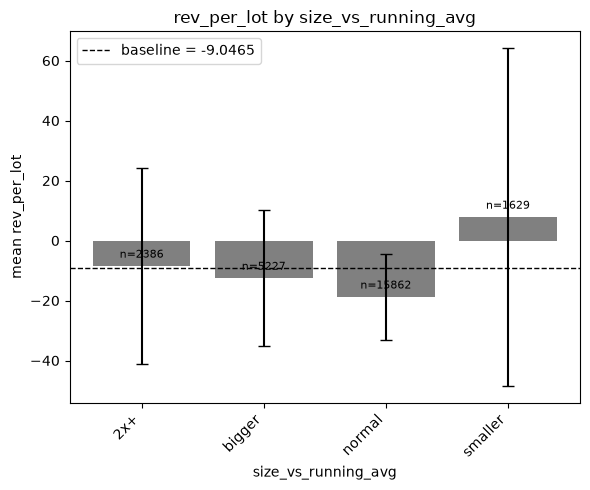

Flip point: lowest bucket with mean rev_per_lot > 0 is 'smaller'

trade_seq_in_campaign


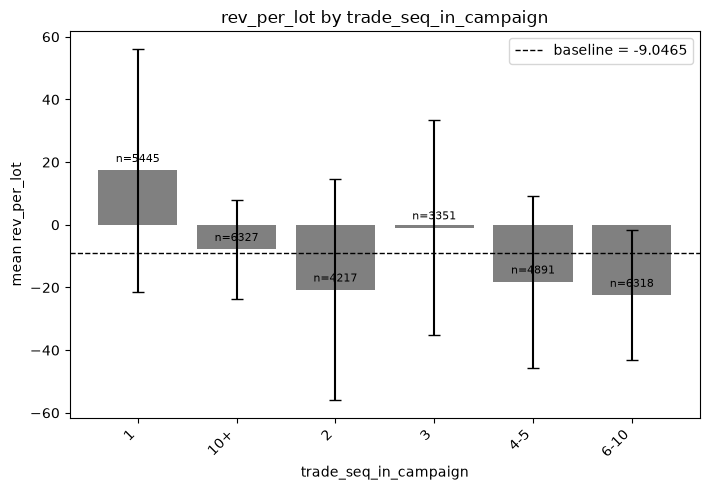

Flip point: lowest bucket with mean rev_per_lot > 0 is '1'

hour_of_day


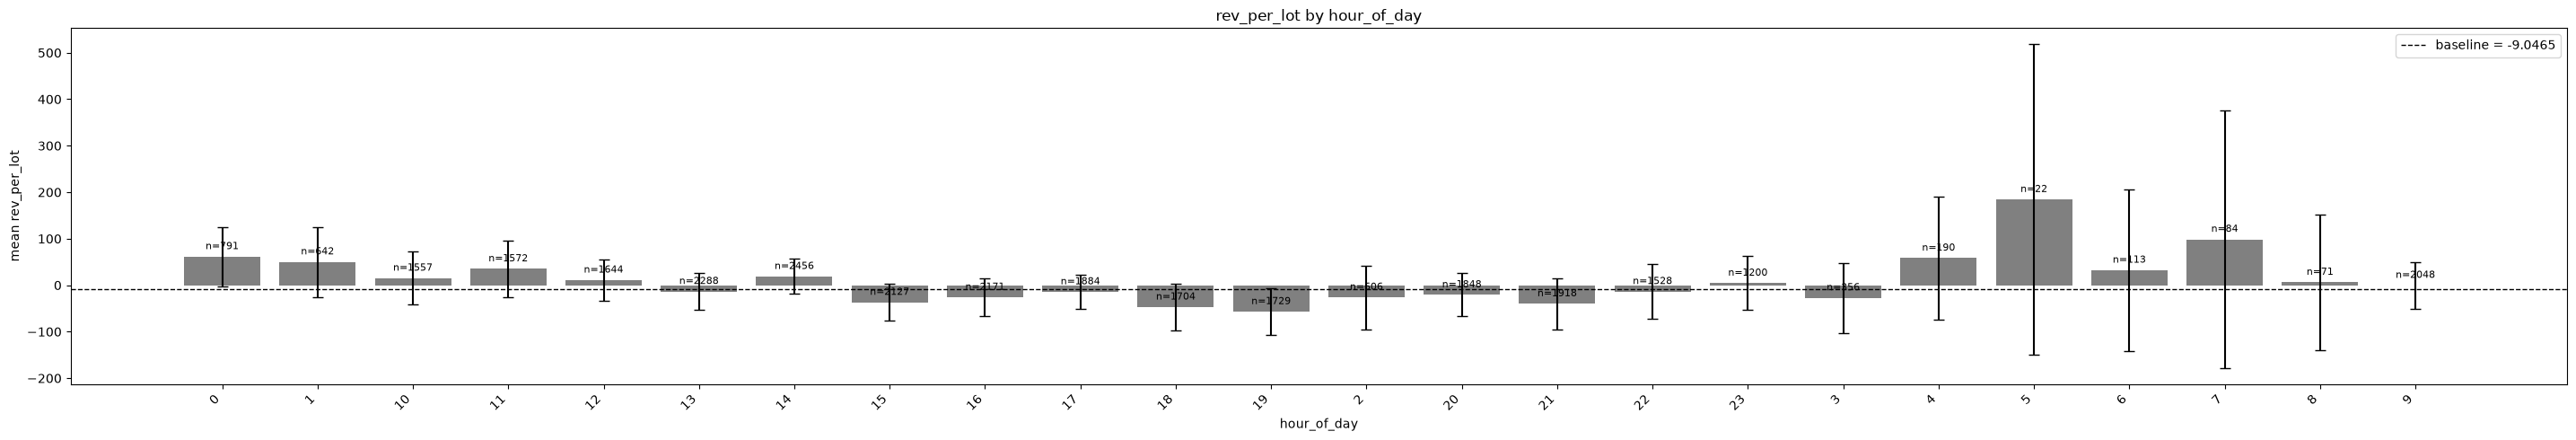

Flip point: lowest bucket with mean rev_per_lot > 0 is '0'

has_SL


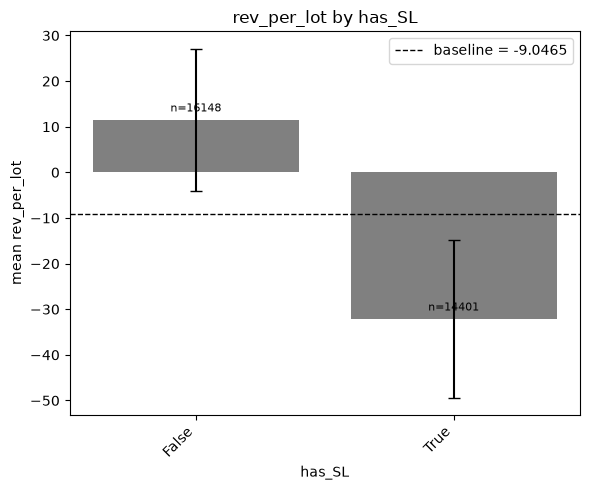

Flip point: lowest bucket with mean rev_per_lot > 0 is 'False'

SUMMARY
             variable flip_point monotonic max_bucket  max_mean_rev_per_lot  max_bucket_n
          loss_streak          1        no          1              686.8220          8514
      reentry_gap_sec    no flip        no       <30s               -8.0635          7021
      dd_pct_of_limit      0-25%       yes      >100%              791.1003          3258
  size_vs_running_avg    smaller        no    smaller                7.8383          1629
trade_seq_in_campaign          1        no          1               17.3893          5445
          hour_of_day          0        no          5              184.3182            22
               has_SL      False       yes      False               11.5205         16148


,variable,flip_point,monotonic,max_bucket,max_mean_rev_per_lot,max_bucket_n
0,loss_streak,1,no,1,686.8220,8514
1,reentry_gap_sec,no flip,no,<30s,-8.0635,7021
2,dd_pct_of_limit,0-25%,yes,>100%,791.1003,3258
3,size_vs_running_avg,smaller,no,smaller,7.8383,1629
4,trade_seq_in_campaign,1,no,1,17.3893,5445
5,hour_of_day,0,no,5,184.3182,22
6,has_SL,False,yes,False,11.5205,16148


In [33]:
discovery_baseline = discovery_df["rev_per_lot"].mean()
print(f"Discovery baseline mean rev_per_lot: {discovery_baseline:.4f}\n")

sweep_specs = [
    ("loss_streak", [-0.5, 0.5, 1.5, 2.5, 3.5, 100], ["0", "1", "2", "3", "4+"]),
    ("reentry_gap_sec", [0, 30, 120, 600, 1e9], ["<30s", "30-120s", "2-10m", ">10m"]),
    ("dd_pct_of_limit", [0, .25, .5, .75, 1.0, 100], ["0-25%", "25-50%", "50-75%", "75-100%", ">100%"]),
    ("size_vs_running_avg", [0, .75, 1.25, 2.0, 100], ["smaller", "normal", "bigger", "2x+"]),
    ("trade_seq_in_campaign", [0, 1, 2, 3, 5, 10, 100], ["1", "2", "3", "4-5", "6-10", "10+"]),
    ("hour_of_day", [h - 0.5 for h in range(25)], [str(h) for h in range(24)]),
    ("has_SL", None, None),
]

sweep_results = {}
for var, bins, labels in sweep_specs:
    print(f"\n{'=' * 60}\n{var}\n{'=' * 60}")
    sweep_results[var] = sweep(discovery_df, var, bins=bins, baseline_rev_per_lot=discovery_baseline, labels=labels)

# --- summary table ---
summary_rows = []
for var, result in sweep_results.items():
    vals = result["mean_rev_per_lot"].values
    monotonic = bool(np.all(np.diff(vals) >= 0) or np.all(np.diff(vals) <= 0)) if len(vals) > 1 else True

    flip = result[result["mean_rev_per_lot"] > 0]
    flip_point = str(flip.iloc[0]["bucket"]) if len(flip) else "no flip"

    max_row = result.loc[result["mean_rev_per_lot"].idxmax()]

    summary_rows.append({
        "variable": var,
        "flip_point": flip_point,
        "monotonic": "yes" if monotonic else "no",
        "max_bucket": str(max_row["bucket"]),
        "max_mean_rev_per_lot": round(max_row["mean_rev_per_lot"], 4),
        "max_bucket_n": int(max_row["n"]),
    })

summary_df = pd.DataFrame(summary_rows)
print(f"\n{'=' * 60}\nSUMMARY\n{'=' * 60}")
print(summary_df.to_string(index=False))
summary_df

A) loss_streak >= 1
Observed mean rev_per_lot (state trades): 584.9061
Null distribution: mean=175.2989, std=4.5260
Two-sided p-value: 0.0000
Verdict: REAL: the state timing carries signal beyond trader identity


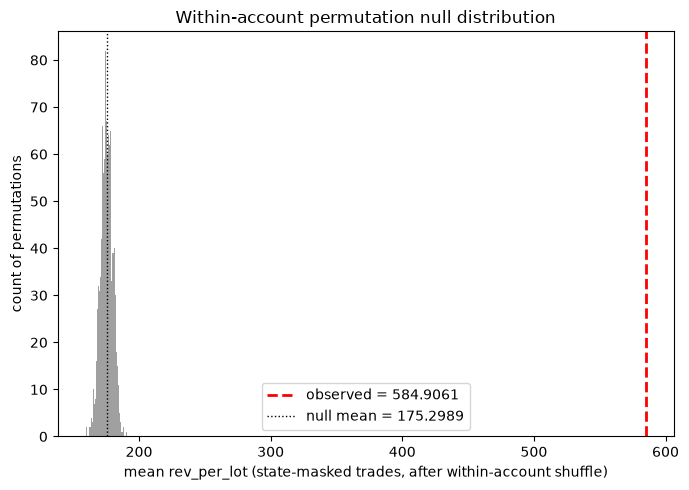


B) dd_pct_of_limit > 0.75
Observed mean rev_per_lot (state trades): 673.8393
Null distribution: mean=130.9730, std=10.7180
Two-sided p-value: 0.0000
Verdict: REAL: the state timing carries signal beyond trader identity


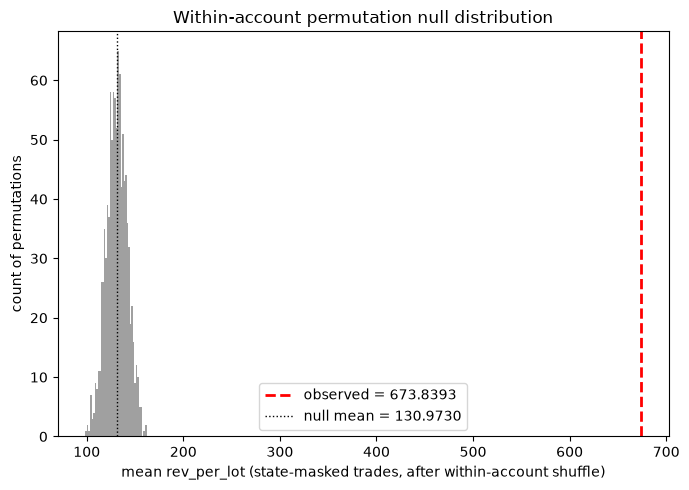


C) has_SL == False
Observed mean rev_per_lot (state trades): 11.5205
Null distribution: mean=2.2128, std=2.8439
Two-sided p-value: 0.0010
Verdict: REAL: the state timing carries signal beyond trader identity


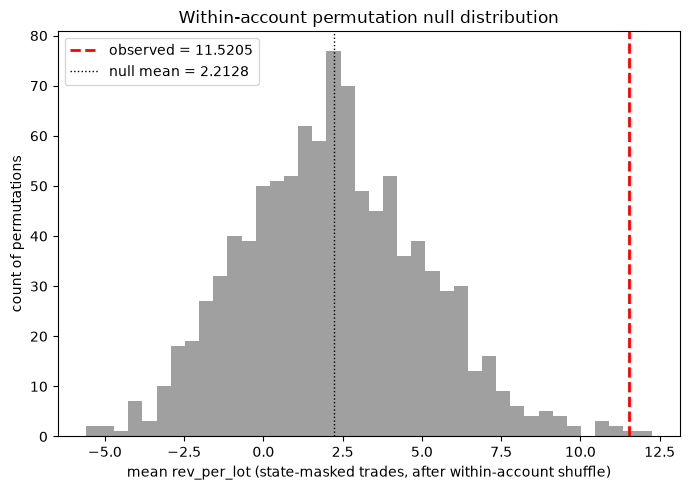

In [34]:
def permutation_test(df, state_mask, n_perm=1000, seed=0):
    rng = np.random.default_rng(seed)

    mask = state_mask.to_numpy() if hasattr(state_mask, "to_numpy") else np.asarray(state_mask)
    rev = df["rev_per_lot"].to_numpy()
    observed = rev[mask].mean()

    # Group each trade by (traderId, campaignId) — permutations only ever
    # shuffle rev_per_lot among a group's OWN trades, never across groups.
    group_id = df.groupby(["traderId", "campaignId"], sort=False).ngroup().to_numpy()

    # Vectorised within-group shuffle: sort rows by group once (orig_order).
    # For each permutation, sort by (group, random priority) — this reorders
    # rows WITHIN each group block randomly while keeping the same group
    # blocks in the same relative order, so assigning position-for-position
    # between the two orderings implements an independent shuffle per group,
    # with no Python-level loop over groups needed.
    orig_order = np.argsort(group_id, kind="stable")
    n = len(df)

    null_means = np.empty(n_perm)
    for i in range(n_perm):
        priority = rng.random(n)
        perm_order = np.lexsort((priority, group_id))
        shuffled_rev = np.empty(n)
        shuffled_rev[orig_order] = rev[perm_order]
        null_means[i] = shuffled_rev[mask].mean()

    null_mean = null_means.mean()
    null_std = null_means.std(ddof=1)

    diff_obs = abs(observed - null_mean)
    p_value = np.mean(np.abs(null_means - null_mean) >= diff_obs)

    if p_value < 0.05 and diff_obs > 2 * null_std:
        verdict = "REAL: the state timing carries signal beyond trader identity"
    else:
        verdict = "ARTEFACT: edge is explained by which traders are in this state, not the state itself"

    print(f"Observed mean rev_per_lot (state trades): {observed:.4f}")
    print(f"Null distribution: mean={null_mean:.4f}, std={null_std:.4f}")
    print(f"Two-sided p-value: {p_value:.4f}")
    print(f"Verdict: {verdict}")

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(null_means, bins=40, color="grey", alpha=0.75)
    ax.axvline(observed, color="red", linestyle="--", linewidth=2,
               label=f"observed = {observed:.4f}")
    ax.axvline(null_mean, color="black", linestyle=":", linewidth=1,
               label=f"null mean = {null_mean:.4f}")
    ax.set_xlabel("mean rev_per_lot (state-masked trades, after within-account shuffle)")
    ax.set_ylabel("count of permutations")
    ax.set_title("Within-account permutation null distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return {
        "observed": observed,
        "null_mean": null_mean,
        "null_std": null_std,
        "p_value": p_value,
        "verdict": verdict,
        "null_means": null_means,
    }


print("=" * 60, "\nA) loss_streak >= 1\n", "=" * 60, sep="")
result_A = permutation_test(discovery_df, discovery_df["loss_streak"] >= 1, n_perm=1000, seed=0)

print("\n" + "=" * 60, "\nB) dd_pct_of_limit > 0.75\n", "=" * 60, sep="")
result_B = permutation_test(discovery_df, discovery_df["dd_pct_of_limit"] > 0.75, n_perm=1000, seed=0)

print("\n" + "=" * 60, "\nC) has_SL == False\n", "=" * 60, sep="")
result_C = permutation_test(discovery_df, discovery_df["has_SL"] == False, n_perm=1000, seed=0)


Confirmation baseline mean rev_per_lot: 2.0938
Discovery baseline mean rev_per_lot:    -9.0465


dd_pct_of_limit — CONFIRMATION


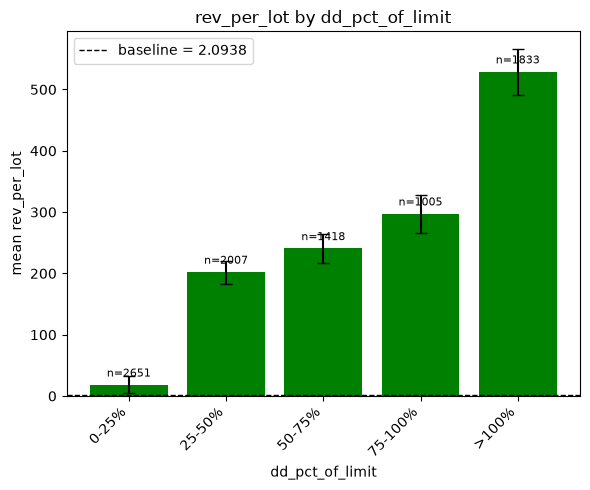

Flip point: lowest bucket with mean rev_per_lot > 0 is '0-25%'

loss_streak — CONFIRMATION


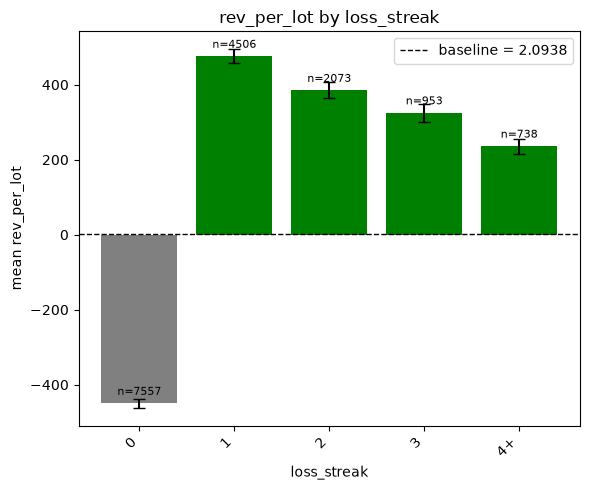

Flip point: lowest bucket with mean rev_per_lot > 0 is '1'

has_SL — CONFIRMATION


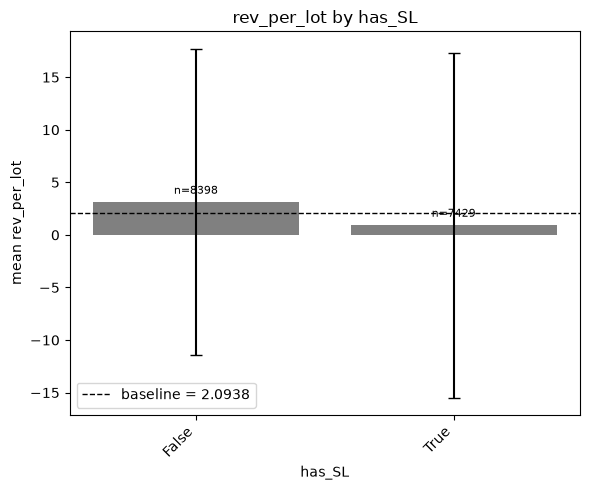

Flip point: lowest bucket with mean rev_per_lot > 0 is 'False'

DISCOVERY vs CONFIRMATION COMPARISON


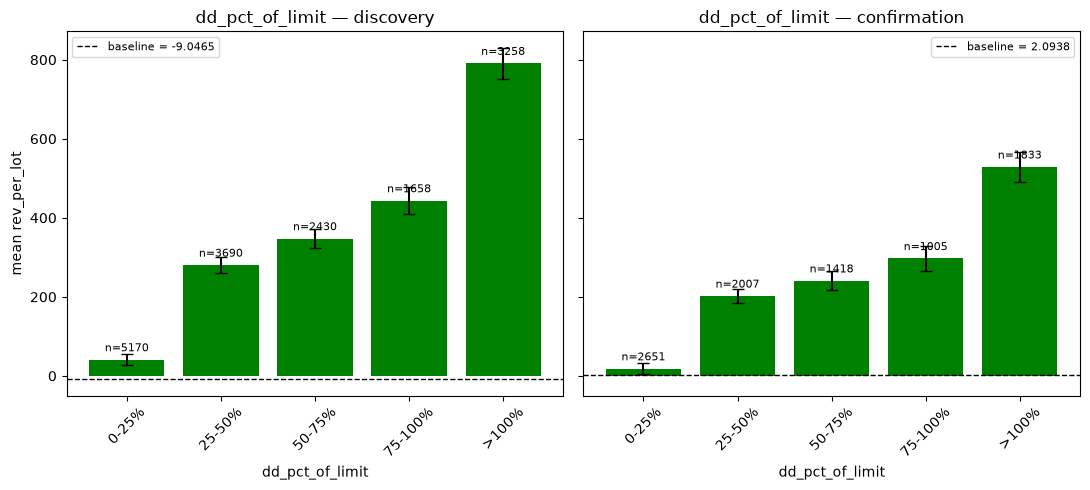


--- dd_pct_of_limit ---
  discovery flip point:    0-25%
  confirmation flip point: 0-25%
  Flip point holds on confirmation: YES
  Top bucket — discovery: '>100%' (mean=791.1003, n=3258)
  Top bucket — confirmation: '>100%' (mean=528.8532, n=1833)
  Same sign on top bucket: YES
  Holds up on confirmation.


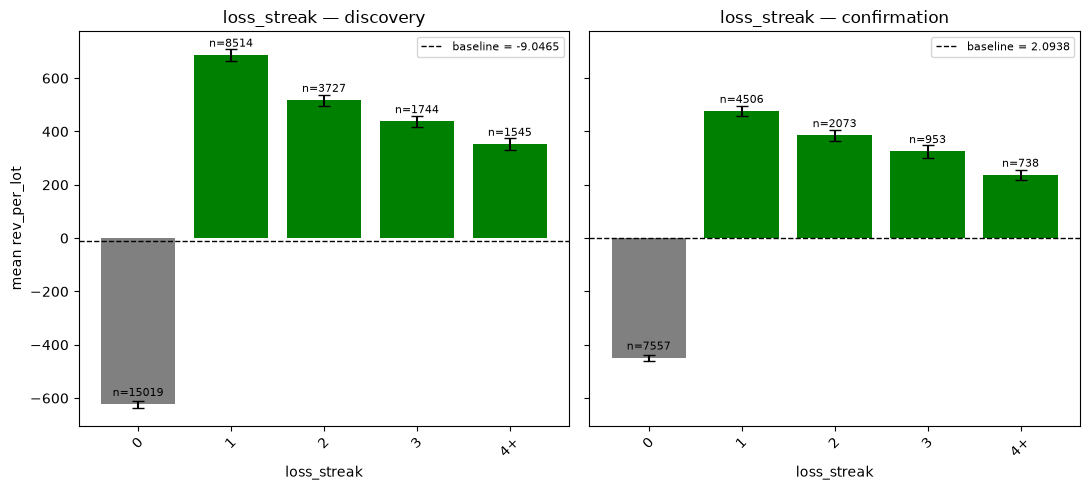


--- loss_streak ---
  discovery flip point:    1
  confirmation flip point: 1
  Flip point holds on confirmation: YES
  Top bucket — discovery: '1' (mean=686.8220, n=8514)
  Top bucket — confirmation: '1' (mean=476.0989, n=4506)
  Same sign on top bucket: YES
  Holds up on confirmation.


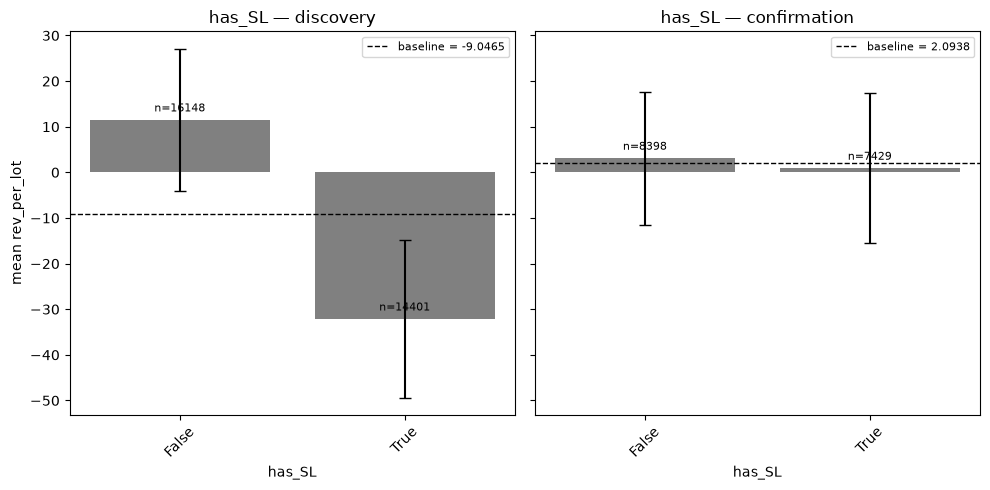


--- has_SL ---
  discovery flip point:    False
  confirmation flip point: False
  Flip point holds on confirmation: YES
  Top bucket — discovery: 'False' (mean=11.5205, n=16148)
  Top bucket — confirmation: 'False' (mean=3.1198, n=8398)
  Same sign on top bucket: YES
  FLAG: COLLAPSES TOWARD BASELINE on confirmation (discovery edge=20.5670, confirmation edge=1.0260)


In [35]:
confirmation_baseline = confirmation_df["rev_per_lot"].mean()
print(f"Confirmation baseline mean rev_per_lot: {confirmation_baseline:.4f}")
print(f"Discovery baseline mean rev_per_lot:    {discovery_baseline:.4f}\n")

confirm_specs = [
    ("dd_pct_of_limit", [0, .25, .5, .75, 1.0, 100], ["0-25%", "25-50%", "50-75%", "75-100%", ">100%"]),
    ("loss_streak", [-0.5, 0.5, 1.5, 2.5, 3.5, 100], ["0", "1", "2", "3", "4+"]),
    ("has_SL", None, None),
]

confirmation_results = {}
for var, bins, labels in confirm_specs:
    print(f"\n{'=' * 60}\n{var} — CONFIRMATION\n{'=' * 60}")
    confirmation_results[var] = sweep(
        confirmation_df, var, bins=bins, baseline_rev_per_lot=confirmation_baseline, labels=labels
    )

# --- side-by-side discovery vs confirmation charts ---
def _flip_point(result):
    flip = result[result["mean_rev_per_lot"] > 0]
    return str(flip.iloc[0]["bucket"]) if len(flip) else "no flip"


def _plot_side_by_side(var, disc_result, conf_result, disc_baseline, conf_baseline):
    fig, axes = plt.subplots(1, 2, figsize=(max(10, len(disc_result) * 2.2), 5), sharey=True)
    for ax, result, baseline, title in [
        (axes[0], disc_result, disc_baseline, "discovery"),
        (axes[1], conf_result, conf_baseline, "confirmation"),
    ]:
        x_labels = result["bucket"].astype(str)
        yerr_low = result["mean_rev_per_lot"] - result["ci_low"]
        yerr_high = result["ci_high"] - result["mean_rev_per_lot"]
        colors = np.where(result["ci_low"] > 0, "green", "grey")
        bars = ax.bar(
            x_labels, result["mean_rev_per_lot"],
            yerr=[yerr_low.fillna(0), yerr_high.fillna(0)],
            capsize=4, color=colors,
        )
        ax.axhline(baseline, linestyle="--", color="black", linewidth=1,
                   label=f"baseline = {baseline:.4f}")
        for bar, n in zip(bars, result["n"]):
            ax.annotate(f"n={n}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        textcoords="offset points", xytext=(0, 6), ha="center", fontsize=8)
        ax.set_title(f"{var} — {title}")
        ax.set_xlabel(var)
        ax.legend(fontsize=8)
        ax.tick_params(axis="x", rotation=45)
    axes[0].set_ylabel("mean rev_per_lot")
    plt.tight_layout()
    plt.show()


print(f"\n{'=' * 60}\nDISCOVERY vs CONFIRMATION COMPARISON\n{'=' * 60}")
for var, bins, labels in confirm_specs:
    disc_result = sweep_results[var]
    conf_result = confirmation_results[var]
    _plot_side_by_side(var, disc_result, conf_result, discovery_baseline, confirmation_baseline)

    disc_flip = _flip_point(disc_result)
    conf_flip = _flip_point(conf_result)
    flip_holds = disc_flip == conf_flip

    disc_top = disc_result.loc[disc_result["mean_rev_per_lot"].idxmax()]
    conf_top = conf_result.loc[conf_result["mean_rev_per_lot"].idxmax()]
    same_sign = np.sign(disc_top["mean_rev_per_lot"]) == np.sign(conf_top["mean_rev_per_lot"])

    disc_edge = disc_top["mean_rev_per_lot"] - discovery_baseline
    conf_edge = conf_top["mean_rev_per_lot"] - confirmation_baseline
    collapses = (disc_edge != 0) and (abs(conf_edge) < 0.25 * abs(disc_edge))
    reverses = not same_sign

    print(f"\n--- {var} ---")
    print(f"  discovery flip point:    {disc_flip}")
    print(f"  confirmation flip point: {conf_flip}")
    print(f"  Flip point holds on confirmation: {'YES' if flip_holds else 'NO'}")
    print(f"  Top bucket — discovery: '{disc_top['bucket']}' (mean={disc_top['mean_rev_per_lot']:.4f}, n={int(disc_top['n'])})")
    print(f"  Top bucket — confirmation: '{conf_top['bucket']}' (mean={conf_top['mean_rev_per_lot']:.4f}, n={int(conf_top['n'])})")
    print(f"  Same sign on top bucket: {'YES' if same_sign else 'NO'}")
    if reverses:
        print(f"  FLAG: REVERSES SIGN on confirmation")
    if collapses:
        print(f"  FLAG: COLLAPSES TOWARD BASELINE on confirmation "
              f"(discovery edge={disc_edge:.4f}, confirmation edge={conf_edge:.4f})")
    if not reverses and not collapses:
        print("  Holds up on confirmation.")


## Method 3 : Interactions 

In [36]:
dd_bins = [0, .25, .5, .75, 1.0, 100]
dd_labels = ["0-25%", "25-50%", "50-75%", "75-100%", ">100%"]
streak_bins = [-0.5, 0.5, 1.5, 2.5, 3.5, 100]
streak_labels = ["0", "1", "2", "3", "4+"]

cross = discovery_df.copy()
cross["dd_bucket"] = pd.cut(cross["dd_pct_of_limit"], bins=dd_bins, labels=dd_labels)
cross["streak_bucket"] = pd.cut(cross["loss_streak"], bins=streak_bins, labels=streak_labels)

grid = cross.groupby(["dd_bucket", "streak_bucket"], observed=False).agg(
    mean_rev_per_lot=("rev_per_lot", "mean"),
    sum_reverseProfit=("reverseProfit", "sum"),
    n=("rev_per_lot", "size"),
).reset_index()

mean_grid = grid.pivot(index="dd_bucket", columns="streak_bucket", values="mean_rev_per_lot")
sum_grid = grid.pivot(index="dd_bucket", columns="streak_bucket", values="sum_reverseProfit")
n_grid = grid.pivot(index="dd_bucket", columns="streak_bucket", values="n")

print("=" * 70)
print("dd_pct_of_limit (rows) x loss_streak (cols) — mean rev_per_lot")
print("=" * 70)
print(mean_grid.round(4))

print("\n" + "=" * 70)
print("dd_pct_of_limit (rows) x loss_streak (cols) — sum reverseProfit")
print("=" * 70)
print(sum_grid.round(2))

print("\n" + "=" * 70)
print("dd_pct_of_limit (rows) x loss_streak (cols) — n")
print("=" * 70)
print(n_grid)


# --- redundancy vs additive read on the combined top-corner cell ---
def redundancy_check(df, baseline, label):
    combined_mask = (df["dd_pct_of_limit"] >= 0.75) & (df["loss_streak"] >= 2)
    dd_mask = df["dd_pct_of_limit"] >= 0.75
    streak_mask = df["loss_streak"] >= 2

    combined_mean = df.loc[combined_mask, "rev_per_lot"].mean()
    dd_mean = df.loc[dd_mask, "rev_per_lot"].mean()
    streak_mean = df.loc[streak_mask, "rev_per_lot"].mean()

    combined_edge = combined_mean - baseline
    dd_edge = dd_mean - baseline
    streak_edge = streak_mean - baseline

    larger_single_edge = max(abs(dd_edge), abs(streak_edge))
    ratio = abs(combined_edge) / larger_single_edge if larger_single_edge != 0 else np.nan

    print(f"\n--- {label} ---")
    print(f"  Combined top-corner (dd_pct_of_limit>=0.75 AND loss_streak>=2): "
          f"mean rev_per_lot={combined_mean:.4f}, n={combined_mask.sum()}")
    print(f"  dd_pct_of_limit>=0.75 alone: mean rev_per_lot={dd_mean:.4f}, n={dd_mask.sum()}")
    print(f"  loss_streak>=2 alone:        mean rev_per_lot={streak_mean:.4f}, n={streak_mask.sum()}")
    print(f"  baseline mean rev_per_lot: {baseline:.4f}")
    print(f"  edges (mean - baseline) — combined: {combined_edge:.4f}, "
          f"dd-only: {dd_edge:.4f}, streak-only: {streak_edge:.4f}")
    print(f"  Ratio (combined edge / larger single edge) = {ratio:.2f}")

    verdict = "redundant" if ratio < 1.3 else "additive"
    explanation = (
        "combined signal is about the same size as the stronger single predictor — "
        "the two flags are mostly flagging the same trades"
        if verdict == "redundant" else
        "combined effect is meaningfully bigger than either single predictor — "
        "a real interaction, not just overlap"
    )
    print(f"  Verdict: {verdict.upper()} ({explanation})")
    return verdict, ratio


disc_verdict, disc_ratio = redundancy_check(discovery_df, discovery_baseline, "DISCOVERY")
conf_verdict, conf_ratio = redundancy_check(confirmation_df, confirmation_baseline, "CONFIRMATION")

print(f"\nVerdict consistent across discovery/confirmation: "
      f"{'YES' if disc_verdict == conf_verdict else 'NO'} "
      f"(discovery: {disc_verdict}, ratio={disc_ratio:.2f}; "
      f"confirmation: {conf_verdict}, ratio={conf_ratio:.2f})")


dd_pct_of_limit (rows) x loss_streak (cols) — mean rev_per_lot
streak_bucket         0          1         2         3        4+
dd_bucket                                                       
0-25%         -411.4229   256.6989  266.6348  233.9530  171.5500
25-50%        -389.3169   542.3799  460.6686  357.8526  326.7932
50-75%        -361.2132   649.6291  555.4698  406.6493  301.0571
75-100%       -338.7642   746.1790  675.3538  501.0182  335.1655
>100%         -358.1792  1456.9373  784.2616  572.4911  417.3566

dd_pct_of_limit (rows) x loss_streak (cols) — sum reverseProfit
streak_bucket         0          1          2         3        4+
dd_bucket                                                        
0-25%         -74955.82   31725.70   12348.38   2053.65    519.68
25-50%        -45459.24   73190.62   39121.58   9295.11   3422.41
50-75%        -26629.30   53378.38   40901.44  15490.39   7585.37
75-100%       -14338.72   47122.91   33030.89  16406.42   9980.74
>100%         -13841.

Dropped 5445 rows with NaN in 'reentry_gap_sec' or 'size_vs_running_avg'

reentry_gap_sec (rows) x size_vs_running_avg (cols) — DISCOVERY

mean rev_per_lot:
_col         2x+   bigger   normal  smaller
_row                                       
2-10m    -4.3367 -15.2834 -40.7187 -26.5312
30-120s -19.3154 -30.4722  -2.9448  22.3771
<30s    -24.2044   4.1511 -13.4775  31.7467
>10m     21.7448 -18.3714 -13.9453   5.6488

sum reverseProfit:
_col         2x+   bigger    normal  smaller
_row                                        
2-10m   -1098.12 -3745.51 -17820.02  -680.19
30-120s -2517.59 -5860.08  -1255.70   166.31
<30s    -6287.48  3307.53  -7028.35  -734.42
>10m     1652.24  -122.44  -5217.39 -1432.09

n:
_col     2x+  bigger  normal  smaller
_row                                 
2-10m    442    1088    4140      351
30-120s  510    1145    2904      369
<30s     874    1803    3999      345
>10m     558    1189    4816      563


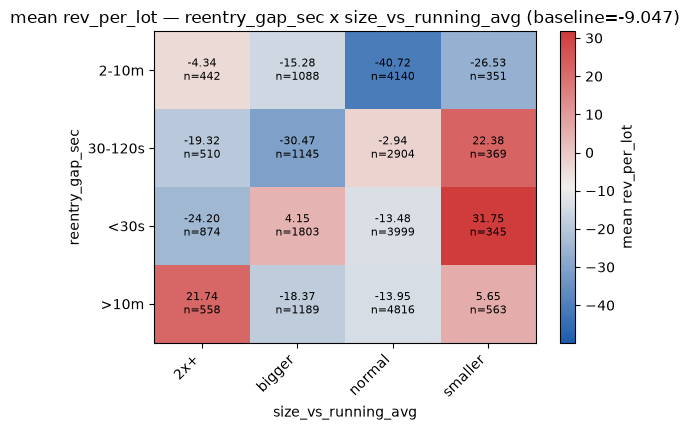


Hottest cell (n>=100): reentry_gap_sec=<30s, size_vs_running_avg=smaller -> mean rev_per_lot=31.7467, n=345
  vs confirmation baseline (2.0938): diff=+29.6529

Single-variable flatness — reentry_gap_sec: NOT flat, size_vs_running_avg: NOT flat
  No flagged cells for this pair (either not both parents flat, or no cell clears n>=100 with CI>0).

(no Method 2 sweep on record for 'has_TP' — running one now)


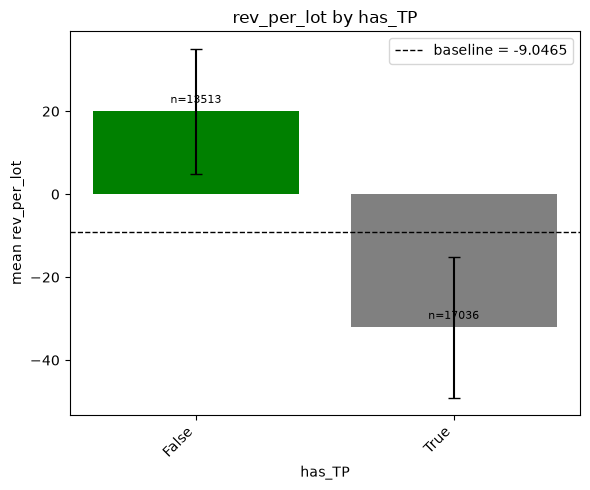

Flip point: lowest bucket with mean rev_per_lot > 0 is 'False'
Dropped 5445 rows with NaN in 'has_TP' or 'size_vs_running_avg'

has_TP (rows) x size_vs_running_avg (cols) — DISCOVERY

mean rev_per_lot:
_col       2x+   bigger   normal  smaller
_row                                     
False  32.8948   5.9032  17.8423  36.4934
True  -61.7065 -32.1243 -42.7189 -20.7114

sum reverseProfit:
_col        2x+   bigger    normal  smaller
_row                                       
False   7038.99  3378.98   9707.88  -352.13
True  -15180.84 -9605.43 -41011.16 -2390.07

n:
_col    2x+  bigger  normal  smaller
_row                                
False  1342    2694    6267      813
True   1044    2533    9595      816


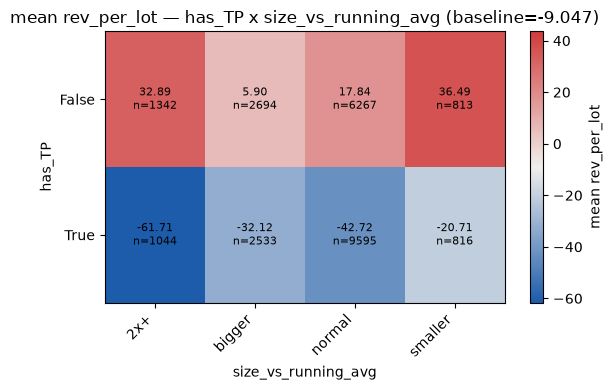


Hottest cell (n>=100): has_TP=False, size_vs_running_avg=smaller -> mean rev_per_lot=36.4934, n=813
  vs confirmation baseline (2.0938): diff=+34.3996

Single-variable flatness — has_TP: NOT flat, size_vs_running_avg: NOT flat
  No flagged cells for this pair (either not both parents flat, or no cell clears n>=100 with CI>0).

(no Method 2 sweep on record for 'side' — running one now)


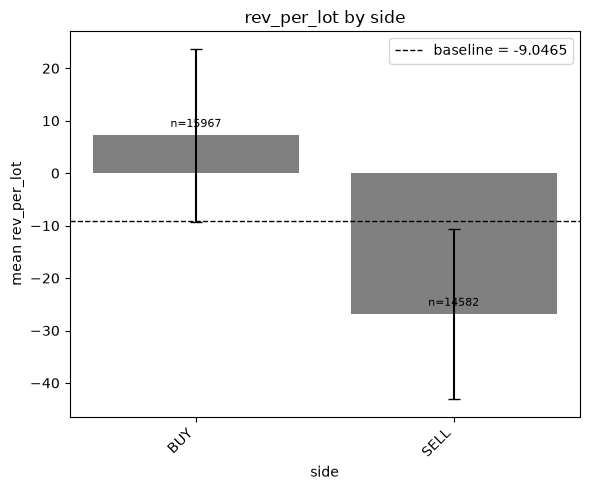

Flip point: lowest bucket with mean rev_per_lot > 0 is 'BUY'
Dropped 5445 rows with NaN in 'side' or 'reentry_gap_sec'

side (rows) x reentry_gap_sec (cols) — DISCOVERY

mean rev_per_lot:
_col    2-10m  30-120s     <30s     >10m
_row                                    
BUY  -40.6095  14.6801  19.4791  -8.0860
SELL -24.2123 -35.0149 -38.3835 -12.7751

sum reverseProfit:
_col     2-10m   30-120s      <30s     >10m
_row                                       
BUY   -7194.72   2002.82   7121.14 -1107.25
SELL -16149.12 -11469.88 -17863.86 -4012.44

n:
_col  2-10m  30-120s  <30s  >10m
_row                            
BUY    3089     2566  3679  3699
SELL   2932     2362  3342  3427


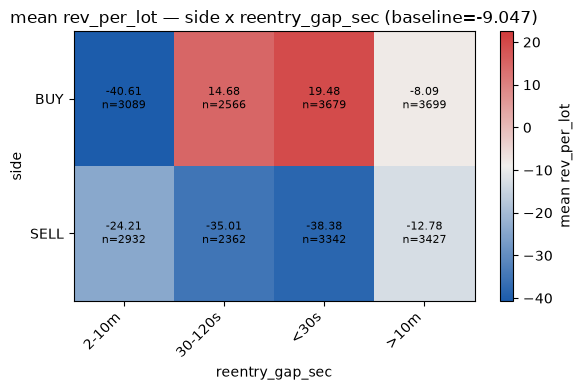


Hottest cell (n>=100): side=BUY, reentry_gap_sec=<30s -> mean rev_per_lot=19.4791, n=3679
  vs confirmation baseline (2.0938): diff=+17.3853

Single-variable flatness — side: NOT flat, reentry_gap_sec: NOT flat
  No flagged cells for this pair (either not both parents flat, or no cell clears n>=100 with CI>0).
Dropped 5445 rows with NaN in 'trade_seq_in_campaign' or 'size_vs_running_avg'

trade_seq_in_campaign (rows) x size_vs_running_avg (cols) — DISCOVERY

mean rev_per_lot:
_col      2x+   bigger   normal   smaller
_row                                     
10+  -25.0179  -8.5883  -0.8110  -66.0764
2    -27.9735 -84.8498 -10.8779   27.4560
3    -29.3798  26.6798 -19.1994  100.2759
4-5   43.3277 -18.9714 -33.2534   37.4165
6-10  -2.0835  -3.2334 -30.8570  -28.6936

sum reverseProfit:
_col      2x+   bigger    normal  smaller
_row                                     
10+  -2517.00 -1130.78  -8109.33 -1070.14
2       38.74 -5847.34  -5419.36 -1187.04
3    -3830.90  3158.77  -3506.15  -3

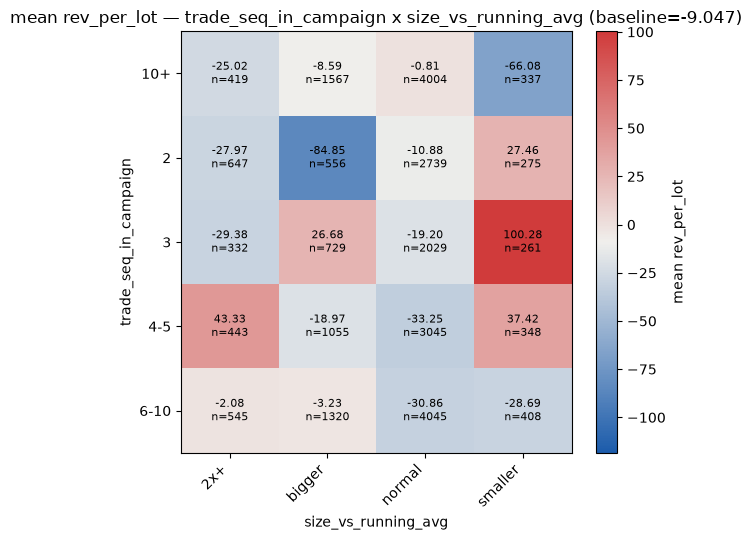


Hottest cell (n>=100): trade_seq_in_campaign=3, size_vs_running_avg=smaller -> mean rev_per_lot=100.2759, n=261
  vs confirmation baseline (2.0938): diff=+98.1821

Single-variable flatness — trade_seq_in_campaign: NOT flat, size_vs_running_avg: NOT flat
  No flagged cells for this pair (either not both parents flat, or no cell clears n>=100 with CI>0).

No genuine-interaction cells were flagged across these four pairs.


In [37]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

# diverging pair from the palette (blue negative / gray midpoint / red positive)
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "blue_gray_red", ["#1c5cab", "#f0efec", "#d03b3b"]
)

var_specs = {
    "reentry_gap_sec": ([0, 30, 120, 600, 1e9], ["<30s", "30-120s", "2-10m", ">10m"]),
    "size_vs_running_avg": ([0, .75, 1.25, 2.0, 100], ["smaller", "normal", "bigger", "2x+"]),
    "trade_seq_in_campaign": ([0, 1, 2, 3, 5, 10, 100], ["1", "2", "3", "4-5", "6-10", "10+"]),
    "has_TP": (None, None),
    "side": (None, None),
}


def _bucket(df, var):
    bins, labels = var_specs[var]
    if bins is None:
        return df[var]
    return pd.cut(df[var], bins=bins, labels=labels)


def _cell_ci(vals):
    n = len(vals)
    mean = vals.mean()
    if n >= 2 and vals.std(ddof=1) > 0:
        sem = vals.std(ddof=1) / np.sqrt(n)
        t_crit = stats.t.ppf(0.975, df=n - 1)
        return mean, mean - t_crit * sem, mean + t_crit * sem
    return mean, np.nan, np.nan


def _is_flat(result_df):
    """True if no bucket's 95% CI is entirely above or below zero."""
    sig = (result_df["ci_low"] > 0) | (result_df["ci_high"] < 0)
    return not sig.fillna(False).any()


def _get_single_sweep(var):
    if var in sweep_results:
        return sweep_results[var]
    bins, labels = var_specs[var]
    print(f"\n(no Method 2 sweep on record for '{var}' — running one now)")
    result = sweep(discovery_df, var, bins=bins, baseline_rev_per_lot=discovery_baseline, labels=labels)
    sweep_results[var] = result
    return result


def interaction_grid(row_var, col_var, df=discovery_df, label="DISCOVERY"):
    n_before = len(df)
    work = df.dropna(subset=[row_var, col_var]).copy()
    n_dropped = n_before - len(work)
    if n_dropped:
        print(f"Dropped {n_dropped} rows with NaN in '{row_var}' or '{col_var}'")

    work["_row"] = _bucket(work, row_var)
    work["_col"] = _bucket(work, col_var)

    rows = []
    for (r, c), g in work.groupby(["_row", "_col"], observed=True):
        mean, ci_low, ci_high = _cell_ci(g["rev_per_lot"])
        rows.append({
            "_row": r, "_col": c, "mean": mean, "n": len(g),
            "sum_reverseProfit": g["reverseProfit"].sum(),
            "ci_low": ci_low, "ci_high": ci_high,
        })
    cell_stats = pd.DataFrame(rows)

    mean_grid = cell_stats.pivot(index="_row", columns="_col", values="mean")
    sum_grid = cell_stats.pivot(index="_row", columns="_col", values="sum_reverseProfit")
    n_grid = cell_stats.pivot(index="_row", columns="_col", values="n")

    print(f"\n{'=' * 70}\n{row_var} (rows) x {col_var} (cols) — {label}\n{'=' * 70}")
    print("\nmean rev_per_lot:")
    print(mean_grid.round(4))
    print("\nsum reverseProfit:")
    print(sum_grid.round(2))
    print("\nn:")
    print(n_grid)

    return cell_stats, mean_grid, sum_grid, n_grid, work


def plot_heatmap(mean_grid, n_grid, row_var, col_var, baseline):
    vmax_abs = np.nanmax(np.abs(mean_grid.to_numpy() - baseline))
    vmax_abs = vmax_abs if vmax_abs > 0 else 1.0
    norm = TwoSlopeNorm(vmin=baseline - vmax_abs, vcenter=baseline, vmax=baseline + vmax_abs)

    fig, ax = plt.subplots(figsize=(max(6, mean_grid.shape[1] * 1.4), max(4, mean_grid.shape[0] * 1.1)))
    im = ax.imshow(mean_grid.to_numpy(), cmap=DIVERGING_CMAP, norm=norm, aspect="auto")

    ax.set_xticks(range(len(mean_grid.columns)))
    ax.set_xticklabels(mean_grid.columns.astype(str), rotation=45, ha="right")
    ax.set_yticks(range(len(mean_grid.index)))
    ax.set_yticklabels(mean_grid.index.astype(str))
    ax.set_xlabel(col_var)
    ax.set_ylabel(row_var)
    ax.set_title(f"mean rev_per_lot — {row_var} x {col_var} (baseline={baseline:.3f})")

    for i in range(mean_grid.shape[0]):
        for j in range(mean_grid.shape[1]):
            val = mean_grid.iat[i, j]
            n_val = n_grid.iat[i, j]
            if pd.isna(val):
                ax.text(j, i, "—", ha="center", va="center", color="grey", fontsize=8)
                continue
            n_txt = "" if pd.isna(n_val) else f"\nn={int(n_val)}"
            ax.text(j, i, f"{val:.2f}{n_txt}", ha="center", va="center",
                     color="black", fontsize=8)

    fig.colorbar(im, ax=ax, label="mean rev_per_lot")
    plt.tight_layout()
    plt.show()


def hottest_cell(cell_stats, min_n=100):
    eligible = cell_stats[cell_stats["n"] >= min_n]
    if eligible.empty:
        return None
    return eligible.loc[eligible["mean"].idxmax()]


def flagged_interactions(cell_stats, row_var, col_var, row_flat, col_flat, min_n=100):
    if not (row_flat and col_flat):
        return cell_stats.iloc[0:0]
    candidates = cell_stats[(cell_stats["n"] >= min_n) & (cell_stats["ci_low"] > 0)]
    return candidates


pairs = [
    ("reentry_gap_sec", "size_vs_running_avg"),
    ("has_TP", "size_vs_running_avg"),
    ("side", "reentry_gap_sec"),
    ("trade_seq_in_campaign", "size_vs_running_avg"),
]

all_flags = []

for row_var, col_var in pairs:
    row_sweep = _get_single_sweep(row_var)
    col_sweep = _get_single_sweep(col_var)
    row_flat = _is_flat(row_sweep)
    col_flat = _is_flat(col_sweep)

    cell_stats, mean_grid, sum_grid, n_grid, _ = interaction_grid(row_var, col_var)
    plot_heatmap(mean_grid, n_grid, row_var, col_var, discovery_baseline)

    hot = hottest_cell(cell_stats, min_n=100)
    if hot is not None:
        diff = hot["mean"] - confirmation_baseline
        print(f"\nHottest cell (n>=100): {row_var}={hot['_row']}, {col_var}={hot['_col']} "
              f"-> mean rev_per_lot={hot['mean']:.4f}, n={int(hot['n'])}")
        print(f"  vs confirmation baseline ({confirmation_baseline:.4f}): diff={diff:+.4f}")
    else:
        print("\nNo cell reaches n>=100.")

    print(f"\nSingle-variable flatness — {row_var}: {'FLAT' if row_flat else 'NOT flat'}, "
          f"{col_var}: {'FLAT' if col_flat else 'NOT flat'}")

    flags = flagged_interactions(cell_stats, row_var, col_var, row_flat, col_flat, min_n=100)
    if len(flags):
        for _, cell in flags.iterrows():
            print(f"  >>> GENUINE INTERACTION FLAG: {row_var}={cell['_row']}, {col_var}={cell['_col']} "
                  f"-> mean rev_per_lot={cell['mean']:.4f} (CI [{cell['ci_low']:.4f}, {cell['ci_high']:.4f}]), "
                  f"n={int(cell['n'])} — both parents flat individually, "
                  f"Method 2 alone could not have found this.")
            all_flags.append((row_var, col_var, cell["_row"], cell["_col"], cell["mean"], cell["n"]))
    else:
        print("  No flagged cells for this pair (either not both parents flat, or no cell clears n>=100 with CI>0).")

# --- confirm any flagged cells on confirmation_df ---
if all_flags:
    print(f"\n{'=' * 70}\nCONFIRMING FLAGGED INTERACTIONS ON confirmation_df\n{'=' * 70}")
    for row_var, col_var, row_bucket, col_bucket, disc_mean, disc_n in all_flags:
        work = confirmation_df.dropna(subset=[row_var, col_var]).copy()
        work["_row"] = _bucket(work, row_var)
        work["_col"] = _bucket(work, col_var)
        cell_vals = work.loc[(work["_row"] == row_bucket) & (work["_col"] == col_bucket), "rev_per_lot"]
        if len(cell_vals) == 0:
            print(f"  {row_var}={row_bucket}, {col_var}={col_bucket}: no matching trades in confirmation set — CANNOT CONFIRM")
            continue
        mean, ci_low, ci_high = _cell_ci(cell_vals)
        holds = (not pd.isna(ci_low)) and ci_low > 0
        print(f"  {row_var}={row_bucket}, {col_var}={col_bucket}: discovery mean={disc_mean:.4f} (n={int(disc_n)}) "
              f"-> confirmation mean={mean:.4f} (n={len(cell_vals)}, CI [{ci_low:.4f}, {ci_high:.4f}]) "
              f"-> {'CONFIRMED' if holds else 'DOES NOT HOLD — do not trust this cell'}")
else:
    print("\nNo genuine-interaction cells were flagged across these four pairs.")


Dropped 5445 rows with NaN in 'dd_pct_of_limit' or 'size_vs_running_avg'

dd_pct_of_limit (rows) x size_vs_running_avg (cols) — DISCOVERY

mean rev_per_lot:
_col          2x+    bigger    normal   smaller
_row                                           
0-25%     69.9581   -7.5231   32.6105  161.6489
25-50%   292.2620  219.7604  281.8193  427.5735
50-75%   341.5216  308.3442  354.6208  454.5853
75-100%  457.2837  417.3786  439.1775  563.6289
>100%    684.8626  695.9042  844.8983  956.5810

sum reverseProfit:
_col          2x+     bigger     normal  smaller
_row                                            
0-25%    -1838.42   -9551.33  -19024.88  2106.22
25-50%    6686.66   10309.80   56523.60  6050.43
50-75%    9525.52   19374.66   58968.61  2857.48
75-100%  14688.48   22271.92   51661.42  3580.43
>100%    64593.85  107346.06  245128.09  6678.99

n:
_col     2x+  bigger  normal  smaller
_row                                 
0-25%    387     970    3284      529
25-50%   265     700    24

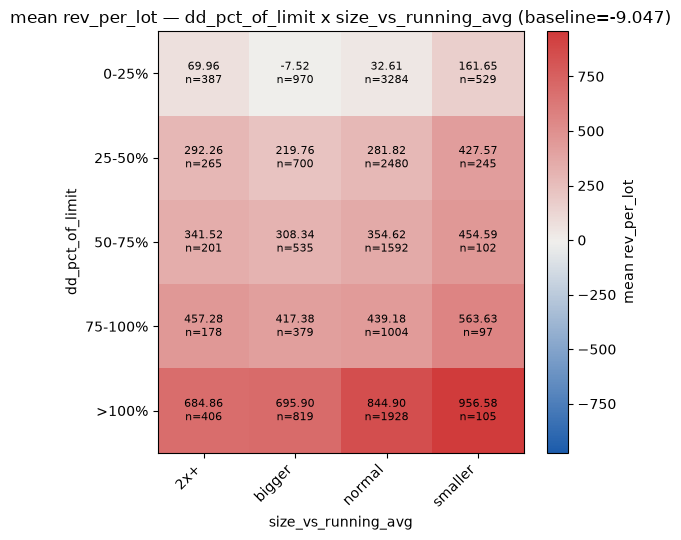


Hottest cell (n>=100): dd_pct_of_limit=>100%, size_vs_running_avg=smaller -> mean rev_per_lot=956.5810, n=105

Within top drawdown row ('>100%') — DISCOVERY
spread of mean rev_per_lot across size_vs_running_avg buckets
   _col       mean    n     ci_low     ci_high
    2x+ 684.862562  406 604.907208  764.817916
 bigger 695.904151  819 632.673982  759.134321
 normal 844.898340 1928 792.566830  897.229851
smaller 956.580952  105 517.126696 1396.035208

Spread (max - min mean rev_per_lot) within top drawdown row: 271.7184
  Highest: smaller (mean=956.5810, CI=[517.1267, 1396.0352], n=105)
  Lowest:  2x+ (mean=684.8626, CI=[604.9072, 764.8179], n=406)

Verdict (DISCOVERY): FLAT across size — drawdown alone carries the signal; size_vs_running_avg adds nothing extra within high drawdown.
Dropped 2683 rows with NaN in 'dd_pct_of_limit' or 'size_vs_running_avg'

dd_pct_of_limit (rows) x size_vs_running_avg (cols) — CONFIRMATION

mean rev_per_lot:
_col          2x+    bigger    normal   smalle

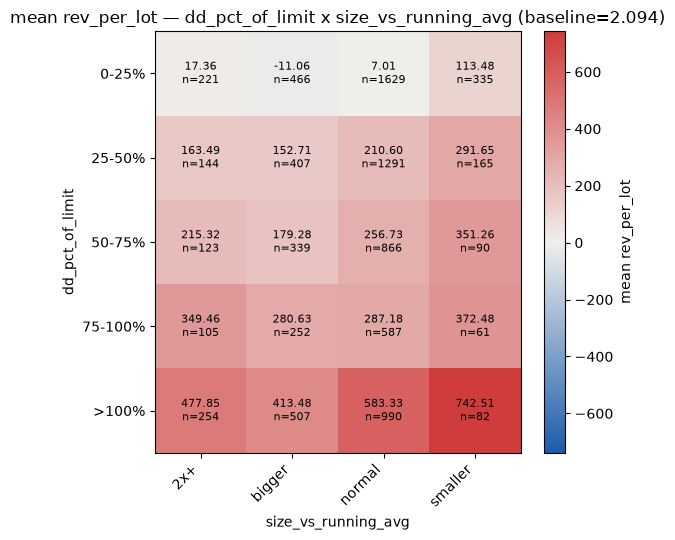


Within top drawdown row ('>100%') — CONFIRMATION
spread of mean rev_per_lot across size_vs_running_avg buckets
   _col       mean   n     ci_low     ci_high
    2x+ 477.850394 254 399.292720  556.408067
 bigger 413.475345 507 354.064237  472.886453
 normal 583.329198 990 531.206164  635.452233
smaller 742.512195  82 400.928681 1084.095710

Spread (max - min mean rev_per_lot) within top drawdown row: 329.0368
  Highest: smaller (mean=742.5122, CI=[400.9287, 1084.0957], n=82)
  Lowest:  bigger (mean=413.4753, CI=[354.0642, 472.8865], n=507)

Verdict (CONFIRMATION): FLAT across size — drawdown alone carries the signal; size_vs_running_avg adds nothing extra within high drawdown.

TRACK C SUMMARY
Discovery:    top row='>100%', spread=271.7184, verdict=FLAT
Confirmation: top row='>100%', spread=329.0368, verdict=FLAT
Consistent across discovery/confirmation: YES


In [38]:
# Track C: cross-family interaction — dd_pct_of_limit (Track A survivor axis,
# loss-accumulation family) x size_vs_running_avg (independent family, flat in
# Method 2's own single-variable sweep). Same bin edges as Method 2.

var_specs["dd_pct_of_limit"] = ([0, .25, .5, .75, 1.0, 100], ["0-25%", "25-50%", "50-75%", "75-100%", ">100%"])


def top_row_spread(cell_stats, mean_grid, row_var, col_var, label):
    top_row_label = mean_grid.index[-1]  # deepest-drawdown bucket, i.e. highest dd_pct_of_limit bin
    top_row_cells = cell_stats[cell_stats["_row"] == top_row_label].sort_values("_col")

    print(f"\n{'=' * 70}\nWithin top drawdown row ('{top_row_label}') — {label}\n"
          f"spread of mean rev_per_lot across {col_var} buckets\n{'=' * 70}")
    print(top_row_cells[["_col", "mean", "n", "ci_low", "ci_high"]].to_string(index=False))

    valid = top_row_cells.dropna(subset=["mean"])
    spread = valid["mean"].max() - valid["mean"].min()
    hi = valid.loc[valid["mean"].idxmax()]
    lo = valid.loc[valid["mean"].idxmin()]
    overlap = not (hi["ci_low"] > lo["ci_high"] or lo["ci_low"] > hi["ci_high"])

    print(f"\nSpread (max - min mean rev_per_lot) within top drawdown row: {spread:.4f}")
    print(f"  Highest: {hi['_col']} (mean={hi['mean']:.4f}, CI=[{hi['ci_low']:.4f}, {hi['ci_high']:.4f}], n={int(hi['n'])})")
    print(f"  Lowest:  {lo['_col']} (mean={lo['mean']:.4f}, CI=[{lo['ci_low']:.4f}, {lo['ci_high']:.4f}], n={int(lo['n'])})")

    if overlap:
        verdict = "FLAT"
        print(f"\nVerdict ({label}): FLAT across size — drawdown alone carries the signal; "
              f"size_vs_running_avg adds nothing extra within high drawdown.")
    else:
        verdict = "NOT FLAT"
        print(f"\nVerdict ({label}): NOT FLAT — size_vs_running_avg meaningfully modulates "
              f"reversibility even within high drawdown (a real cross-family interaction).")

    return top_row_label, spread, verdict


# --- discovery ---
cell_stats, mean_grid, sum_grid, n_grid, _ = interaction_grid(
    "dd_pct_of_limit", "size_vs_running_avg", df=discovery_df, label="DISCOVERY"
)
plot_heatmap(mean_grid, n_grid, "dd_pct_of_limit", "size_vs_running_avg", discovery_baseline)

hot = hottest_cell(cell_stats, min_n=100)
if hot is not None:
    print(f"\nHottest cell (n>=100): dd_pct_of_limit={hot['_row']}, size_vs_running_avg={hot['_col']} "
          f"-> mean rev_per_lot={hot['mean']:.4f}, n={int(hot['n'])}")

disc_row_label, disc_spread, disc_verdict = top_row_spread(
    cell_stats, mean_grid, "dd_pct_of_limit", "size_vs_running_avg", "DISCOVERY"
)

# --- confirm on confirmation_df ---
cell_stats_conf, mean_grid_conf, sum_grid_conf, n_grid_conf, _ = interaction_grid(
    "dd_pct_of_limit", "size_vs_running_avg", df=confirmation_df, label="CONFIRMATION"
)
plot_heatmap(mean_grid_conf, n_grid_conf, "dd_pct_of_limit", "size_vs_running_avg", confirmation_baseline)

conf_row_label, conf_spread, conf_verdict = top_row_spread(
    cell_stats_conf, mean_grid_conf, "dd_pct_of_limit", "size_vs_running_avg", "CONFIRMATION"
)

print(f"\n{'=' * 70}\nTRACK C SUMMARY\n{'=' * 70}")
print(f"Discovery:    top row='{disc_row_label}', spread={disc_spread:.4f}, verdict={disc_verdict}")
print(f"Confirmation: top row='{conf_row_label}', spread={conf_spread:.4f}, verdict={conf_verdict}")
print(f"Consistent across discovery/confirmation: {'YES' if disc_verdict == conf_verdict else 'NO'}")


Streak subset (loss_streak >= 2): n=7016, mean rev_per_lot=461.2300
(For reference — full discovery baseline: -9.0465)

size_vs_running_avg — WITHIN STREAK SUBSET (loss_streak>=2)


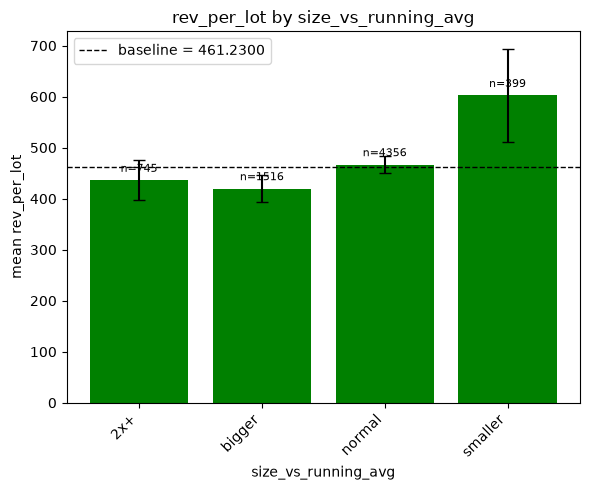

Flip point: lowest bucket with mean rev_per_lot > 0 is '2x+'
  >>> FLAG: size_vs_running_avg=smaller -> mean=602.4962 (CI [511.6512, 693.3412]), n=399, edge over streak baseline=+141.2663

reentry_gap_sec — WITHIN STREAK SUBSET (loss_streak>=2)


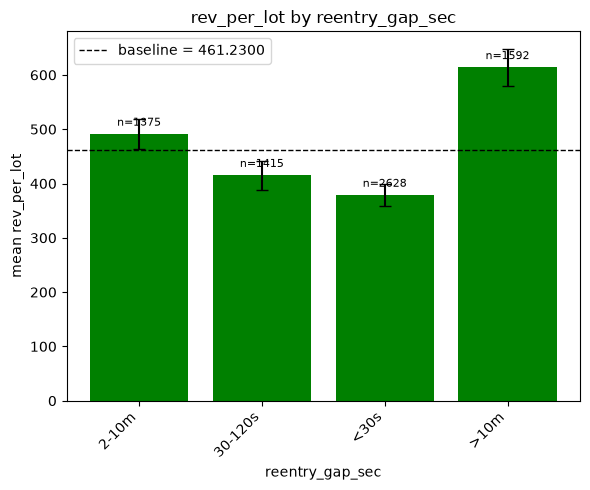

Flip point: lowest bucket with mean rev_per_lot > 0 is '2-10m'
  >>> FLAG: reentry_gap_sec=2-10m -> mean=491.0929 (CI [462.8057, 519.3802]), n=1375, edge over streak baseline=+29.8630
  >>> FLAG: reentry_gap_sec=>10m -> mean=613.8007 (CI [579.7297, 647.8717]), n=1592, edge over streak baseline=+152.5707

has_TP — WITHIN STREAK SUBSET (loss_streak>=2)


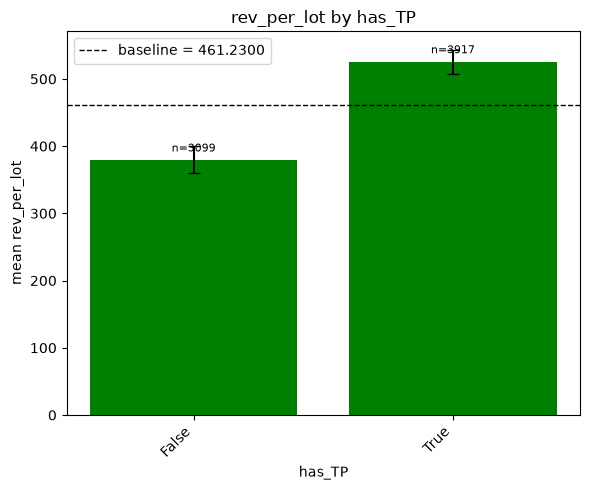

Flip point: lowest bucket with mean rev_per_lot > 0 is 'False'
  >>> FLAG: has_TP=True -> mean=525.8003 (CI [507.9327, 543.6679]), n=3917, edge over streak baseline=+64.5703

side — WITHIN STREAK SUBSET (loss_streak>=2)


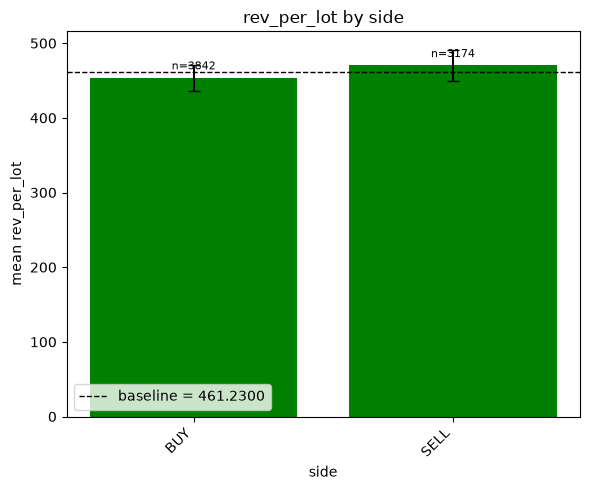

Flip point: lowest bucket with mean rev_per_lot > 0 is 'BUY'
  No buckets clear the streak-state baseline with n>=100.

trade_seq_in_campaign — WITHIN STREAK SUBSET (loss_streak>=2)


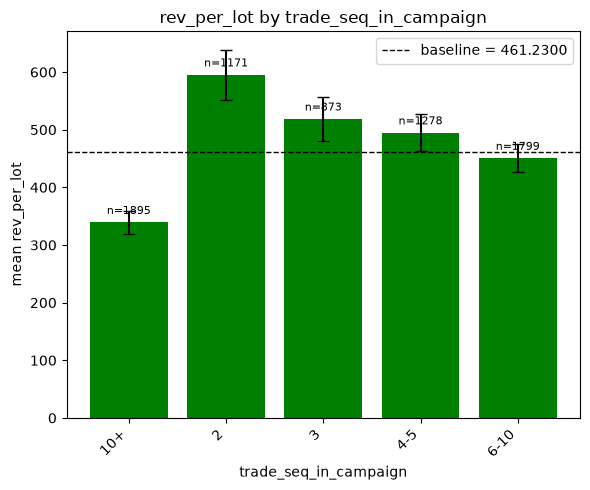

Flip point: lowest bucket with mean rev_per_lot > 0 is '10+'
  >>> FLAG: trade_seq_in_campaign=2 -> mean=595.2936 (CI [551.8423, 638.7449]), n=1171, edge over streak baseline=+134.0636
  >>> FLAG: trade_seq_in_campaign=3 -> mean=518.7407 (CI [480.2284, 557.2529]), n=873, edge over streak baseline=+57.5107
  >>> FLAG: trade_seq_in_campaign=4-5 -> mean=494.8318 (CI [462.8509, 526.8128]), n=1278, edge over streak baseline=+33.6019

CANDIDATE SECOND SIGNALS (ranked by edge over streak baseline)
                  var  bucket       mean     ci_low    ci_high    n       edge
      reentry_gap_sec    >10m 613.800680 579.729663 647.871698 1592 152.570694
  size_vs_running_avg smaller 602.496241 511.651245 693.341236  399 141.266254
trade_seq_in_campaign       2 595.293581 551.842252 638.744910 1171 134.063595
               has_TP    True 525.800302 507.932728 543.667876 3917  64.570316
trade_seq_in_campaign       3 518.740664 480.228411 557.252918  873  57.510678
trade_seq_in_campaign     4-5 

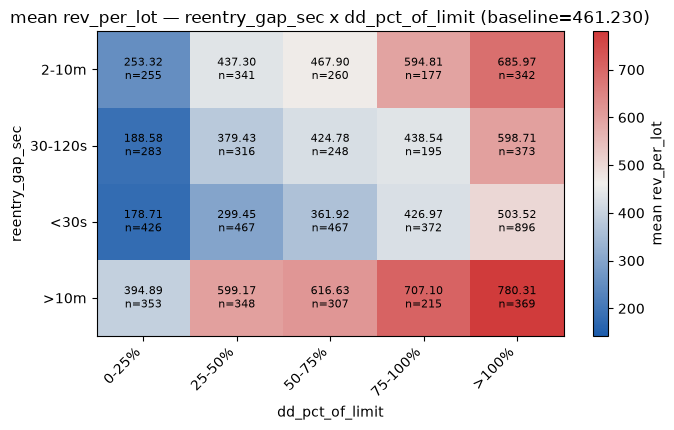


Controlling for drawdown — reentry_gap_sec=>10m vs rest, stratified by dd_pct_of_limit
dd_bucket  n_in  n_rest    mean_in  mean_rest       diff
    0-25%   353     966 394.889235 201.023292 193.865943
   25-50%   348    1124 599.165086 363.755783 235.409303
   50-75%   307     976 616.628122 406.065266 210.562855
  75-100%   215     745 707.097674 469.584161 237.513513
    >100%   369    1613 780.310298 563.923745 216.386554

Original (unstratified) edge: +152.5707
n-weighted average within-stratum edge (controlling for drawdown): +217.2814
Ratio (stratified / original) = 1.42

SURVIVES controlling for drawdown (independent signal)

VERDICT
YES — reentry_gap_sec=>10m separates reversible from non-reversible trades within the streak state, beyond what drawdown already explains.


In [39]:
# --- streak subset ---
streak_subset = discovery_df[discovery_df["loss_streak"] >= 2].copy()
streak_baseline = streak_subset["rev_per_lot"].mean()
print(f"Streak subset (loss_streak >= 2): n={len(streak_subset)}, mean rev_per_lot={streak_baseline:.4f}")
print(f"(For reference — full discovery baseline: {discovery_baseline:.4f})")

# --- single-variable sweeps within the streak subset, judged vs the STREAK baseline ---
streak_specs = [
    ("size_vs_running_avg", [0, .75, 1.25, 2.0, 100], ["smaller", "normal", "bigger", "2x+"]),
    ("reentry_gap_sec", [0, 30, 120, 600, 1e9], ["<30s", "30-120s", "2-10m", ">10m"]),
    ("has_TP", None, None),
    ("side", None, None),
    ("trade_seq_in_campaign", [0, 1, 2, 3, 5, 10, 100], ["1", "2", "3", "4-5", "6-10", "10+"]),
]

streak_sweep_results = {}
flagged_within_streak = []

for var, bins, labels in streak_specs:
    print(f"\n{'=' * 60}\n{var} — WITHIN STREAK SUBSET (loss_streak>=2)\n{'=' * 60}")
    result = sweep(streak_subset, var, bins=bins, baseline_rev_per_lot=streak_baseline, labels=labels)
    streak_sweep_results[var] = result

    # flag buckets whose CI is entirely ABOVE the streak-state baseline (not zero), with n>=100
    sig = result[(result["ci_low"] > streak_baseline) & (result["n"] >= 100)]
    for _, row in sig.iterrows():
        edge = row["mean_rev_per_lot"] - streak_baseline
        print(f"  >>> FLAG: {var}={row['bucket']} -> mean={row['mean_rev_per_lot']:.4f} "
              f"(CI [{row['ci_low']:.4f}, {row['ci_high']:.4f}]), n={int(row['n'])}, "
              f"edge over streak baseline={edge:+.4f}")
        flagged_within_streak.append({
            "var": var, "bucket": row["bucket"], "mean": row["mean_rev_per_lot"],
            "ci_low": row["ci_low"], "ci_high": row["ci_high"], "n": row["n"], "edge": edge,
        })
    if sig.empty:
        print("  No buckets clear the streak-state baseline with n>=100.")

if not flagged_within_streak:
    print("\nNo candidate second signals found within the streak subset.")
    print("\nVERDICT: No behaviour separates reversible from non-reversible trades within the "
          "streak state beyond what drawdown already explains — nothing to test.")
else:
    flagged_df = pd.DataFrame(flagged_within_streak).sort_values("edge", ascending=False)
    print(f"\n{'=' * 60}\nCANDIDATE SECOND SIGNALS (ranked by edge over streak baseline)\n{'=' * 60}")
    print(flagged_df.to_string(index=False))

    winner = flagged_df.iloc[0]
    winning_var, winning_bucket, winning_edge = winner["var"], winner["bucket"], winner["edge"]
    print(f"\nStrongest candidate: {winning_var}={winning_bucket} (edge={winning_edge:+.4f}, n={int(winner['n'])})")

    # --- cross winning variable with dd_pct_of_limit, restricted to the streak subset ---
    bins_map = {v: (b, l) for v, b, l in streak_specs}
    if winning_var not in var_specs:
        var_specs[winning_var] = bins_map[winning_var]
    if "dd_pct_of_limit" not in var_specs:
        var_specs["dd_pct_of_limit"] = ([0, .25, .5, .75, 1.0, 100], ["0-25%", "25-50%", "50-75%", "75-100%", ">100%"])

    cross_cell_stats, cross_mean_grid, cross_sum_grid, cross_n_grid, _ = interaction_grid(
        winning_var, "dd_pct_of_limit", df=streak_subset, label="STREAK SUBSET"
    )
    plot_heatmap(cross_mean_grid, cross_n_grid, winning_var, "dd_pct_of_limit", streak_baseline)

    # stratified check: within each dd_pct_of_limit stratum, does the winning bucket still
    # beat the rest of that stratum? If it collapses stratum by stratum, the "signal" is just
    # re-measuring drawdown (like Track A found for loss_streak itself).
    print(f"\n{'=' * 60}\nControlling for drawdown — {winning_var}={winning_bucket} vs rest, "
          f"stratified by dd_pct_of_limit\n{'=' * 60}")

    work = streak_subset.dropna(subset=[winning_var, "dd_pct_of_limit"]).copy()
    work["_wvar_bucket"] = _bucket(work, winning_var)
    work["_dd_bucket"] = _bucket(work, "dd_pct_of_limit")

    stratum_rows = []
    for dd_b, g in work.groupby("_dd_bucket", observed=True):
        in_bucket = g[g["_wvar_bucket"] == winning_bucket]["rev_per_lot"]
        rest = g[g["_wvar_bucket"] != winning_bucket]["rev_per_lot"]
        if len(in_bucket) < 30 or len(rest) < 30:
            continue
        diff = in_bucket.mean() - rest.mean()
        stratum_rows.append({"dd_bucket": dd_b, "n_in": len(in_bucket), "n_rest": len(rest),
                              "mean_in": in_bucket.mean(), "mean_rest": rest.mean(), "diff": diff})

    if not stratum_rows:
        print("  Not enough data in any drawdown stratum (n>=30 both sides) to check controlling for drawdown.")
        survives = False
        weighted_diff = np.nan
    else:
        stratum_df = pd.DataFrame(stratum_rows)
        print(stratum_df.to_string(index=False))
        total_n = stratum_df["n_in"].sum()
        weighted_diff = (stratum_df["diff"] * stratum_df["n_in"]).sum() / total_n
        ratio = weighted_diff / winning_edge if winning_edge != 0 else np.nan
        print(f"\nOriginal (unstratified) edge: {winning_edge:+.4f}")
        print(f"n-weighted average within-stratum edge (controlling for drawdown): {weighted_diff:+.4f}")
        print(f"Ratio (stratified / original) = {ratio:.2f}")
        survives = (weighted_diff > 0) and (ratio > 0.4)
        print(f"\n{'SURVIVES' if survives else 'DOES NOT SURVIVE'} controlling for drawdown "
              f"({'independent signal' if survives else 'largely explained by drawdown, like Track A found for streak itself'})")

    print(f"\n{'=' * 60}\nVERDICT\n{'=' * 60}")
    if survives:
        print(f"YES — {winning_var}={winning_bucket} separates reversible from non-reversible trades "
              f"within the streak state, beyond what drawdown already explains.")
    else:
        print(f"NO — the strongest within-streak candidate ({winning_var}={winning_bucket}) does not hold up "
              f"once controlling for drawdown; it appears to be re-measuring drawdown rather than an "
              f"independent behavioural signal.")


Streak-subset baseline (discovery): 461.2300 (n=7016)
slow_reentry state mean rev_per_lot (discovery): 613.8007 (CI [579.7297, 647.8717]), n=1592
Edge over streak baseline (discovery): +152.5707

GATE 1 — WITHIN-ACCOUNT PERMUTATION TEST (streak subset universe)
Observed mean rev_per_lot (state trades): 613.8007
Null distribution: mean=603.8179, std=6.3432
Two-sided p-value: 0.1220
Verdict: ARTEFACT: edge is explained by which traders are in this state, not the state itself


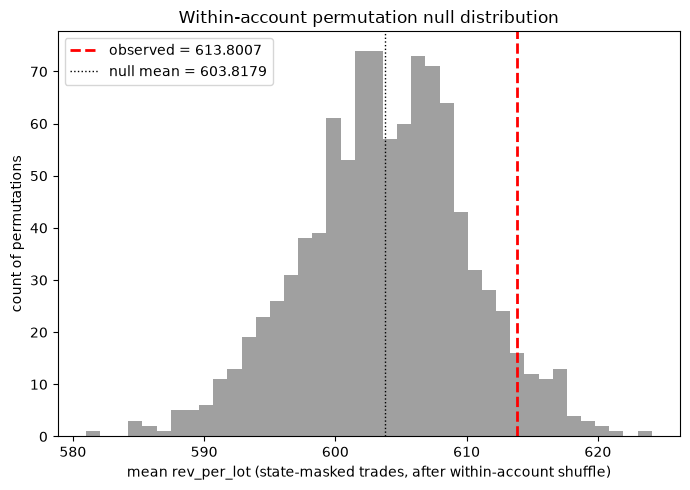


GATE 1 result: p=0.1220 -> FAIL (looks like a trader-quality artefact)

GATE 2 — HELD-OUT CONFIRMATION
Streak-subset baseline (confirmation): 340.8307 (n=3764)
slow_reentry state mean rev_per_lot (confirmation): 466.9654 (CI [429.5993, 504.3315]), n=862
Edge over streak baseline (confirmation): +126.1347

Discovery edge: +152.5707  |  Confirmation edge: +126.1347  |  ratio: 0.83
Same sign: YES

GATE 2 result: PASS

COMBINED VERDICT
NOT CONFIRMED — failed: GATE 1 (permutation test — p not significant, looks like a trader-quality artefact)


In [40]:
# state under test: within the loss-streak subset, slow re-entry after the previous close
# state_mask = (loss_streak >= 2) & (reentry_gap_sec > 600) -- reduces to the reentry
# condition alone once already restricted to streak_subset (loss_streak >= 2)

discovery_state_mask = streak_subset["reentry_gap_sec"] > 600
discovery_state_vals = streak_subset.loc[discovery_state_mask, "rev_per_lot"]
discovery_state_mean, discovery_state_ci_low, discovery_state_ci_high = _cell_ci(discovery_state_vals)
discovery_edge = discovery_state_mean - streak_baseline

print(f"Streak-subset baseline (discovery): {streak_baseline:.4f} (n={len(streak_subset)})")
print(f"slow_reentry state mean rev_per_lot (discovery): {discovery_state_mean:.4f} "
      f"(CI [{discovery_state_ci_low:.4f}, {discovery_state_ci_high:.4f}]), n={len(discovery_state_vals)}")
print(f"Edge over streak baseline (discovery): {discovery_edge:+.4f}")

# ======================================================================
# GATE 1 — within-account permutation test, restricted to the streak subset
# ======================================================================
print(f"\n{'=' * 70}\nGATE 1 — WITHIN-ACCOUNT PERMUTATION TEST (streak subset universe)\n{'=' * 70}")
gate1_result = permutation_test(streak_subset, discovery_state_mask, n_perm=1000, seed=0)
gate1_pass = gate1_result["p_value"] < 0.05
print(f"\nGATE 1 result: p={gate1_result['p_value']:.4f} -> "
      f"{'PASS (real state effect)' if gate1_pass else 'FAIL (looks like a trader-quality artefact)'}")

# ======================================================================
# GATE 2 — held-out confirmation on confirmation_df, same definitions
# ======================================================================
print(f"\n{'=' * 70}\nGATE 2 — HELD-OUT CONFIRMATION\n{'=' * 70}")

confirmation_streak_subset = confirmation_df[confirmation_df["loss_streak"] >= 2].copy()
confirmation_streak_baseline = confirmation_streak_subset["rev_per_lot"].mean()

confirmation_state_mask = confirmation_streak_subset["reentry_gap_sec"] > 600
confirmation_state_vals = confirmation_streak_subset.loc[confirmation_state_mask, "rev_per_lot"]
n_conf = len(confirmation_state_vals)
confirmation_state_mean, confirmation_ci_low, confirmation_ci_high = _cell_ci(confirmation_state_vals)
confirmation_edge = confirmation_state_mean - confirmation_streak_baseline

print(f"Streak-subset baseline (confirmation): {confirmation_streak_baseline:.4f} "
      f"(n={len(confirmation_streak_subset)})")
print(f"slow_reentry state mean rev_per_lot (confirmation): {confirmation_state_mean:.4f} "
      f"(CI [{confirmation_ci_low:.4f}, {confirmation_ci_high:.4f}]), n={n_conf}")
print(f"Edge over streak baseline (confirmation): {confirmation_edge:+.4f}")

same_sign = np.sign(discovery_edge) == np.sign(confirmation_edge)
ratio = confirmation_edge / discovery_edge if discovery_edge != 0 else np.nan
low_n = n_conf < 100
collapsed = (not low_n) and (discovery_edge != 0) and (abs(confirmation_edge) < 0.25 * abs(discovery_edge))
reversed_sign = not same_sign

print(f"\nDiscovery edge: {discovery_edge:+.4f}  |  Confirmation edge: {confirmation_edge:+.4f}  |  "
      f"ratio: {ratio:.2f}" if not pd.isna(ratio) else "\nratio undefined (discovery edge is 0)")
print(f"Same sign: {'YES' if same_sign else 'NO'}")
if low_n:
    print(f"FLAG: confirmation n={n_conf} < 100 — not enough confirmation-set trades in this state cell")
if collapsed:
    print(f"FLAG: edge collapses toward confirmation baseline "
          f"(confirmation edge is < 25% of discovery edge)")
if reversed_sign:
    print(f"FLAG: edge REVERSES SIGN on confirmation")

gate2_pass = same_sign and (not low_n) and (not collapsed)
print(f"\nGATE 2 result: {'PASS' if gate2_pass else 'FAIL'}")

# ======================================================================
# COMBINED VERDICT
# ======================================================================
print(f"\n{'=' * 70}\nCOMBINED VERDICT\n{'=' * 70}")
confirmed = gate1_pass and gate2_pass
if confirmed:
    print("CONFIRMED — slow_reentry within the loss-streak subset passes both the permutation "
          "test and held-out confirmation. Trust this signal.")
else:
    failed_gates = []
    if not gate1_pass:
        failed_gates.append("GATE 1 (permutation test — p not significant, looks like a trader-quality artefact)")
    if not gate2_pass:
        reasons = []
        if not same_sign:
            reasons.append("sign reversed")
        if low_n:
            reasons.append(f"n={n_conf}<100")
        if collapsed:
            reasons.append("edge collapsed toward baseline")
        failed_gates.append(f"GATE 2 (held-out confirmation — {', '.join(reasons)})")
    print("NOT CONFIRMED — failed: " + "; ".join(failed_gates))


# EDA FROM DEVANSHI SG [METHOD 1 : BIASES]

## Bias 1

reentry_gap_pct: 20887 / 30549 non-null (NaN on each campaign's first trade / first reentry opportunity)
prior_was_loss:  11895 True of 30549 non-null
same_dir_after_loss: 6561 True
revenge_state:   4451 True of 30549

revenge_state (prior_was_loss AND reentry_gap_pct < 0.25 — bottom quartile of own speed) vs complement
revenge_state=True:  mean rev_per_lot=7.8091 (CI [-15.1511, 30.7692]), n=4451
revenge_state=False: mean rev_per_lot=-11.9212 (CI [-24.8877, 1.0453]), n=26098
Edge (revenge - complement): +19.7303

reentry_gap_pct quartile sweep — PRIOR-LOSS TRADES ONLY (baseline=-5.4074, n=11895)
Dropped 1965 rows with NaN in 'reentry_gap_pct'


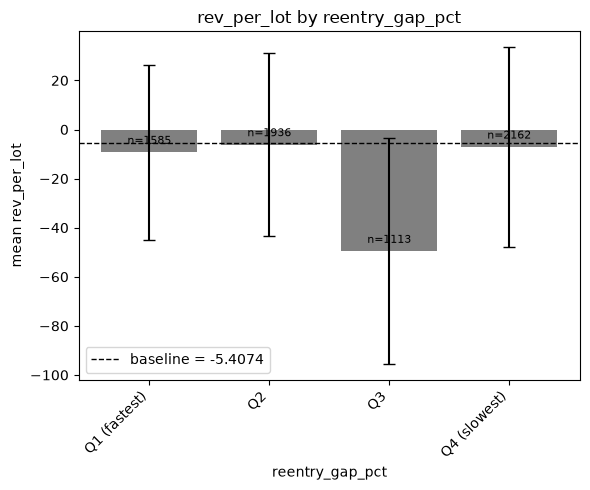

Flip point: no flip


In [41]:
# --- pre-trade metrics on discovery_df ---

work = discovery_df.sort_values(["traderId", "campaignId", "trade_seq_in_campaign"]).copy()


def _expanding_pct_rank_shifted(s):
    """For each row, the fraction of the group's PRIOR (already-seen) values that
    are strictly less than the current value — i.e. this trade's reentry_gap_sec
    expressed as a percentile within this trader's own prior gaps this campaign.
    Low percentile = unusually fast for THIS trader. First trade -> NaN (no prior)."""
    vals = s.to_numpy(dtype=float)
    out = np.full(len(vals), np.nan)
    for i in range(1, len(vals)):
        prior = vals[:i]
        prior = prior[~np.isnan(prior)]
        if len(prior) == 0 or np.isnan(vals[i]):
            continue
        out[i] = (prior < vals[i]).mean()
    return pd.Series(out, index=s.index)


work["reentry_gap_pct"] = (
    work.groupby(["traderId", "campaignId"], group_keys=False)["reentry_gap_sec"]
        .apply(_expanding_pct_rank_shifted)
)

work["prior_netProfit"] = work.groupby(["traderId", "campaignId"])["netProfit"].shift(1)
work["prior_was_loss"] = work["prior_netProfit"] < 0

work["prior_side"] = work.groupby(["traderId", "campaignId"])["side"].shift(1)
work["same_dir_after_loss"] = work["prior_was_loss"].fillna(False) & (work["side"] == work["prior_side"])

work["revenge_state"] = work["prior_was_loss"].fillna(False) & (work["reentry_gap_pct"] < 0.25)

# write back onto discovery_df (index-aligned, so row order doesn't matter)
discovery_df["reentry_gap_pct"] = work["reentry_gap_pct"]
discovery_df["prior_was_loss"] = work["prior_was_loss"]
discovery_df["same_dir_after_loss"] = work["same_dir_after_loss"]
discovery_df["revenge_state"] = work["revenge_state"]

print(f"reentry_gap_pct: {discovery_df['reentry_gap_pct'].notna().sum()} / {len(discovery_df)} non-null "
      f"(NaN on each campaign's first trade / first reentry opportunity)")
print(f"prior_was_loss:  {discovery_df['prior_was_loss'].sum()} True of "
      f"{discovery_df['prior_was_loss'].notna().sum()} non-null")
print(f"same_dir_after_loss: {discovery_df['same_dir_after_loss'].sum()} True")
print(f"revenge_state:   {discovery_df['revenge_state'].sum()} True of {len(discovery_df)}")

# --- revenge_state vs its complement ---
print(f"\n{'=' * 70}\nrevenge_state (prior_was_loss AND reentry_gap_pct < 0.25 — bottom quartile "
      f"of own speed) vs complement\n{'=' * 70}")

revenge_vals = discovery_df.loc[discovery_df["revenge_state"], "rev_per_lot"]
complement_vals = discovery_df.loc[~discovery_df["revenge_state"], "rev_per_lot"]

revenge_mean, revenge_ci_low, revenge_ci_high = _cell_ci(revenge_vals)
complement_mean, complement_ci_low, complement_ci_high = _cell_ci(complement_vals)

print(f"revenge_state=True:  mean rev_per_lot={revenge_mean:.4f} "
      f"(CI [{revenge_ci_low:.4f}, {revenge_ci_high:.4f}]), n={len(revenge_vals)}")
print(f"revenge_state=False: mean rev_per_lot={complement_mean:.4f} "
      f"(CI [{complement_ci_low:.4f}, {complement_ci_high:.4f}]), n={len(complement_vals)}")
print(f"Edge (revenge - complement): {revenge_mean - complement_mean:+.4f}")

# --- quartile sweep of reentry_gap_pct, among prior-loss trades only ---
prior_loss_df = discovery_df[discovery_df["prior_was_loss"] == True].copy()
prior_loss_baseline = prior_loss_df["rev_per_lot"].mean()
print(f"\n{'=' * 70}\nreentry_gap_pct quartile sweep — PRIOR-LOSS TRADES ONLY "
      f"(baseline={prior_loss_baseline:.4f}, n={len(prior_loss_df)})\n{'=' * 70}")

quartile_result = sweep(
    prior_loss_df, "reentry_gap_pct", bins=[0, .25, .5, .75, 1.0],
    baseline_rev_per_lot=prior_loss_baseline,
    labels=["Q1 (fastest)", "Q2", "Q3", "Q4 (slowest)"],
)


## Bias 2

In [42]:
# dd_pct_of_limit — completeness check only (same bins as Method 2). NOT a new signal.
#
# This is the same drawdown effect already swept in Method 2's single-variable pass,
# and Track A (dd_pct_of_limit x loss_streak redundancy check) already showed
# dd_pct_of_limit SUBSUMES loss_streak (the two were found redundant, not additive —
# see Track A's verdict above). Reproduced here only so this section is
# self-contained; do not treat this as an independent finding.

print("=" * 70)
print("dd_pct_of_limit — completeness sweep (cross-reference only)")
print("=" * 70)
print("NOTE: not a new finding. Same drawdown signal already reported in Method 2's")
print("summary table, and already shown by Track A to subsume loss_streak (redundant,")
print("not additive). See Method 2 and Track A above for the substantive interpretation.\n")

print(sweep_results["dd_pct_of_limit"].to_string(index=False))


dd_pct_of_limit — completeness sweep (cross-reference only)
NOTE: not a new finding. Same drawdown signal already reported in Method 2's
summary table, and already shown by Track A to subsume loss_streak (redundant,
not additive). See Method 2 and Track A above for the substantive interpretation.

 bucket    n  mean_rev_per_lot     ci_low    ci_high  sum_reverseProfit  median_amount
  0-25% 5170         41.079634  27.079990  55.079278         -28308.400           0.10
 25-50% 3690        280.474027 260.462729 300.485324          79570.495           0.10
 50-75% 2430        347.544854 322.643333 372.446375          90726.275           0.12
75-100% 1658        443.419300 408.746397 478.092204          92202.250           0.15
  >100% 3258        791.100276 752.235814 829.964739         423746.995           0.20


DAMAGE_CONTROL_INDEX coverage: 82.1% of discovery trades (n=25080 of 30549)

STEP 1 — individual components, quartiles of their within-campaign percentile

--- dd_pct_of_limit_pct ---
Dropped 24 rows with NaN in 'dd_pct_of_limit_pct'


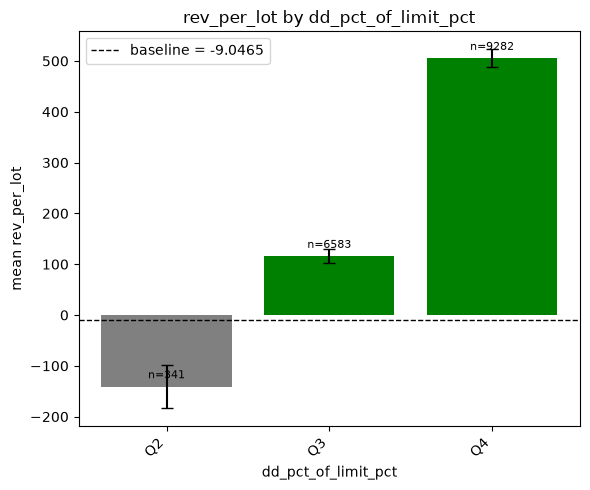

Flip point: lowest bucket with mean rev_per_lot > 0 is 'Q3'
dd_pct_of_limit: CARRIES SIGNAL

--- drawdown_velocity_pct ---
Dropped 5469 rows with NaN in 'drawdown_velocity_pct'


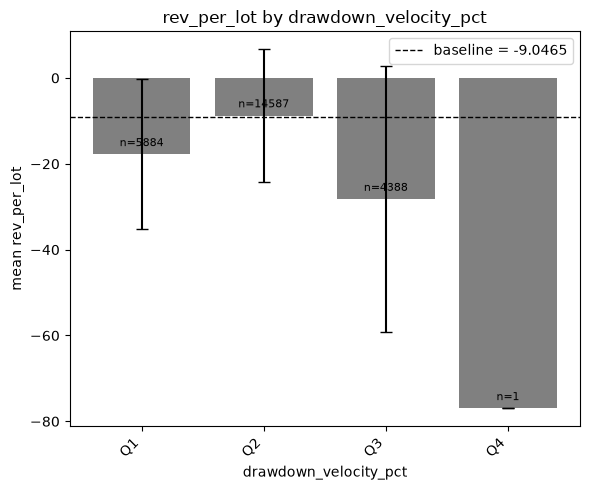

Flip point: no flip
drawdown_velocity: CARRIES SIGNAL

--- trades_since_peak_pct ---
Dropped 5469 rows with NaN in 'trades_since_peak_pct'


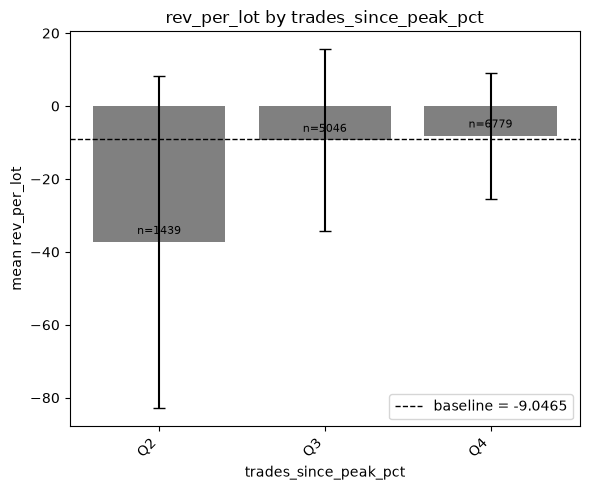

Flip point: no flip
trades_since_peak: FLAT

--- minutes_since_peak_pct ---
Dropped 5469 rows with NaN in 'minutes_since_peak_pct'


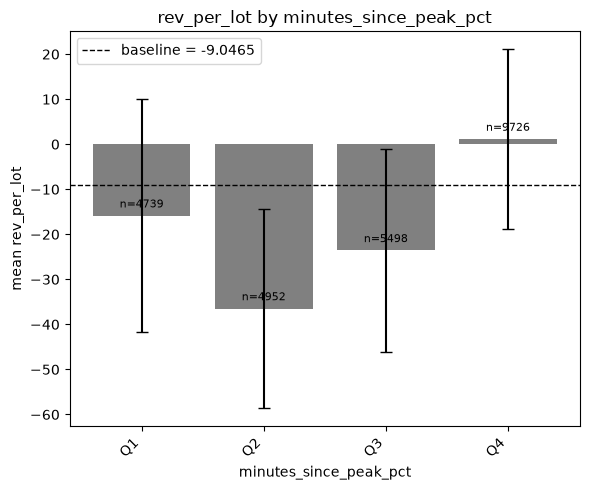

Flip point: lowest bucket with mean rev_per_lot > 0 is 'Q4'
minutes_since_peak: CARRIES SIGNAL

STEP 2 — DAMAGE_CONTROL_INDEX, quartiles
Dropped 5469 rows with NaN in 'DAMAGE_CONTROL_INDEX'


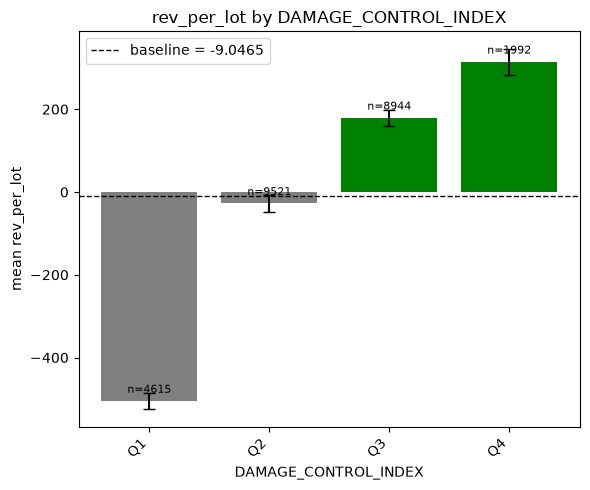

Flip point: lowest bucket with mean rev_per_lot > 0 is 'Q3'

STEP 3 — index vs best single component
Index Q4 edge over baseline: +323.3634 (n=1992)
dd_pct_of_limit Q4 edge over baseline: +514.4510 (n=9282)
drawdown_velocity Q4 edge over baseline: -67.9535 (n=1) [THIN — n<100, excluded from 'best' selection]
trades_since_peak Q4 edge over baseline: +0.8742 (n=6779)
minutes_since_peak Q4 edge over baseline: +10.1789 (n=9726)

Best single component: dd_pct_of_limit (edge=+514.4510)
Index edge: +323.3634  |  Ratio (index / best single) = 0.63

Verdict: DROP INDEX — use the single component (dd_pct_of_limit). Bundling added nothing.

STEP 4 — gates on dd_pct_of_limit top quartile (Q4, within-campaign percentile)

--- Gate (a): within-account permutation test ---
Observed mean rev_per_lot (state trades): 504.6116
Null distribution: mean=103.6249, std=6.5119
Two-sided p-value: 0.0000
Verdict: REAL: the state timing carries signal beyond trader identity


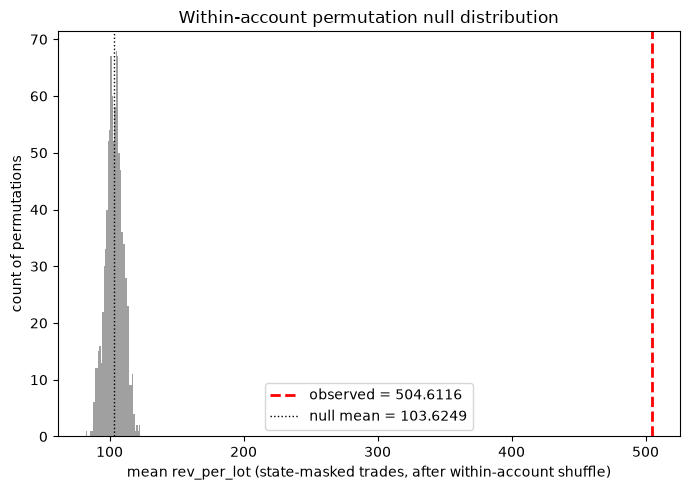


Gate (a): PASS (p=0.0000)

--- Gate (b): held-out confirmation ---
Discovery:    mean rev_per_lot=504.6116 (CI [487.0259, 522.1973]), n=9303, edge=+513.6581
Confirmation: mean rev_per_lot=354.6953 (CI [337.2660, 372.1245]), n=5052, edge=+352.6015

Gate (b): PASS

FINAL VERDICT
Damage Control Index does NOT beat dd_pct_of_limit alone (carrying forward: dd_pct_of_limit top quartile (Q4, within-campaign percentile)), and it SURVIVES both gates (permutation p=0.0000, confirmation holds).


In [43]:
# Damage Control Index (Bias 2 — drawdown family): does bundling 4 drawdown-related
# metrics into one index beat the best single component (dd_pct_of_limit)?

def _peak_recovery_metrics(g):
    """Pre-trade (shift(1)-safe) peak-recovery metrics for one (traderId, campaignId)
    group, sorted by trade_seq_in_campaign. Row 0 (first trade) -> all NaN."""
    n = len(g)
    drawdown_at_open = np.full(n, np.nan)
    trades_since_peak = np.full(n, np.nan)
    minutes_since_peak = np.full(n, np.nan)

    equity = g["equity"].to_numpy()
    running_peak = g["running_peak"].to_numpy()
    drawdown = g["drawdown"].to_numpy()
    close_dt = g["closeDateTime"].to_numpy()
    open_dt = g["openDateTime"].to_numpy()

    is_peak = np.isclose(equity, running_peak)

    last_peak_idx = None
    for i in range(1, n):
        if is_peak[i - 1]:
            last_peak_idx = i - 1
        drawdown_at_open[i] = drawdown[i - 1]
        trades_since_peak[i] = (i - 1) - last_peak_idx
        mins = (open_dt[i] - close_dt[last_peak_idx]) / np.timedelta64(1, "m")
        minutes_since_peak[i] = mins

    return pd.DataFrame(
        {"drawdown_at_open": drawdown_at_open,
         "trades_since_peak": trades_since_peak,
         "minutes_since_peak": minutes_since_peak},
        index=g.index,
    )


def build_damage_control_index(df):
    """Returns a copy of df with the 4 raw components, their within-campaign
    expanding-shifted percentiles, and DAMAGE_CONTROL_INDEX added."""
    work = df.sort_values(["traderId", "campaignId", "trade_seq_in_campaign"]).copy()

    peak_metrics = (
        work.groupby(["traderId", "campaignId"], group_keys=False)
            .apply(_peak_recovery_metrics, include_groups=False)
    )
    work["drawdown_at_open"] = peak_metrics["drawdown_at_open"]
    work["trades_since_peak"] = peak_metrics["trades_since_peak"]
    work["minutes_since_peak"] = peak_metrics["minutes_since_peak"]

    safe_minutes = work["minutes_since_peak"].where(work["minutes_since_peak"] > 0, np.nan)
    work["drawdown_velocity"] = work["drawdown_at_open"] / safe_minutes

    # component 1 reuses the existing dd_pct_of_limit column as-is (unshifted, same
    # column already used everywhere else in this notebook — Method 2 / Track A)
    raw_components = {
        "dd_pct_of_limit": "dd_pct_of_limit",
        "drawdown_velocity": "drawdown_velocity",
        "trades_since_peak": "trades_since_peak",
        "minutes_since_peak": "minutes_since_peak",
    }

    time_ordered = work.sort_values(["campaignId", "openDateTime"])
    for name, raw_col in raw_components.items():
        pct = (
            time_ordered.groupby("campaignId", group_keys=False)[raw_col]
                        .apply(_expanding_pct_rank_shifted)
        )
        work[f"{name}_pct"] = pct  # index-aligned

    # require ALL FOUR present -- an equal-weight average over a partial set isn't
    # the same index, so skipna=False rather than silently averaging over 3
    work["DAMAGE_CONTROL_INDEX"] = work[[f"{n}_pct" for n in raw_components]].mean(axis=1, skipna=False)

    return work


discovery_dci = build_damage_control_index(discovery_df)
coverage_pct = 100 * discovery_dci["DAMAGE_CONTROL_INDEX"].notna().mean()
print(f"DAMAGE_CONTROL_INDEX coverage: {coverage_pct:.1f}% of discovery trades "
      f"(n={discovery_dci['DAMAGE_CONTROL_INDEX'].notna().sum()} of {len(discovery_dci)})\n")

component_names = ["dd_pct_of_limit", "drawdown_velocity", "trades_since_peak", "minutes_since_peak"]

# ======================================================================
# STEP 1 — score each of the four components individually
# ======================================================================
print(f"{'=' * 70}\nSTEP 1 — individual components, quartiles of their within-campaign percentile\n{'=' * 70}")

component_results = {}
component_flat = {}
for name in component_names:
    print(f"\n--- {name}_pct ---")
    result = sweep(
        discovery_dci, f"{name}_pct", bins=[0, .25, .5, .75, 1.0],
        baseline_rev_per_lot=discovery_baseline,
        labels=["Q1", "Q2", "Q3", "Q4"],
    )
    component_results[name] = result
    component_flat[name] = _is_flat(result)
    print(f"{name}: {'FLAT' if component_flat[name] else 'CARRIES SIGNAL'}")

# ======================================================================
# STEP 2 — score DAMAGE_CONTROL_INDEX
# ======================================================================
print(f"\n{'=' * 70}\nSTEP 2 — DAMAGE_CONTROL_INDEX, quartiles\n{'=' * 70}")
index_result = sweep(
    discovery_dci, "DAMAGE_CONTROL_INDEX", bins=[0, .25, .5, .75, 1.0],
    baseline_rev_per_lot=discovery_baseline,
    labels=["Q1", "Q2", "Q3", "Q4"],
)

# ======================================================================
# STEP 3 — index top-quartile edge vs best single component's top-quartile edge
# ======================================================================
print(f"\n{'=' * 70}\nSTEP 3 — index vs best single component\n{'=' * 70}")

index_top = index_result.iloc[-1]  # Q4
index_edge = index_top["mean_rev_per_lot"] - discovery_baseline
print(f"Index Q4 edge over baseline: {index_edge:+.4f} (n={int(index_top['n'])})")

MIN_N = 100
component_edges = {}
component_ns = {}
for name, result in component_results.items():
    top = result.iloc[-1]  # Q4
    edge = top["mean_rev_per_lot"] - discovery_baseline
    component_edges[name] = edge
    component_ns[name] = int(top["n"])
    thin_flag = " [THIN — n<100, excluded from 'best' selection]" if top["n"] < MIN_N else ""
    print(f"{name} Q4 edge over baseline: {edge:+.4f} (n={int(top['n'])}){thin_flag}")

qualifying = {n: e for n, e in component_edges.items() if component_ns[n] >= MIN_N}
if not qualifying:
    print(f"\nWARNING: no component has n>={MIN_N} in Q4 — falling back to comparing all, "
          f"including thin ones (treat this comparison with caution).")
    qualifying = component_edges
best_component_name = max(qualifying, key=qualifying.get)
best_component_edge = component_edges[best_component_name]
ratio = index_edge / best_component_edge if best_component_edge != 0 else np.nan

print(f"\nBest single component: {best_component_name} (edge={best_component_edge:+.4f})")
print(f"Index edge: {index_edge:+.4f}  |  Ratio (index / best single) = {ratio:.2f}")

if index_edge <= best_component_edge:
    step3_verdict = "DROP_INDEX"
    print("\nVerdict: DROP INDEX — use the single component (dd_pct_of_limit). Bundling added nothing.")
elif ratio > 1.3:
    step3_verdict = "KEEP_INDEX"
    print("\nVerdict: KEEP INDEX — bundling helps by a clear margin.")
else:
    step3_verdict = "DROP_INDEX"
    print("\nVerdict: DROP INDEX — index edge is marginally higher but not by a clear margin "
          "(ratio <= 1.3). Use the single component (dd_pct_of_limit).")

# ======================================================================
# STEP 4 — gates on whatever survives Step 3
# ======================================================================
if step3_verdict == "KEEP_INDEX":
    carry_forward_col = "DAMAGE_CONTROL_INDEX"
    carry_forward_label = "DAMAGE_CONTROL_INDEX top quartile (Q4)"
    discovery_state_df = discovery_dci
    discovery_state_mask = discovery_dci["DAMAGE_CONTROL_INDEX"] >= 0.75
else:
    carry_forward_col = "dd_pct_of_limit_pct"
    carry_forward_label = "dd_pct_of_limit top quartile (Q4, within-campaign percentile)"
    discovery_state_df = discovery_dci
    discovery_state_mask = discovery_dci["dd_pct_of_limit_pct"] >= 0.75

print(f"\n{'=' * 70}\nSTEP 4 — gates on {carry_forward_label}\n{'=' * 70}")

print(f"\n--- Gate (a): within-account permutation test ---")
gate_a_result = permutation_test(discovery_state_df, discovery_state_mask, n_perm=1000, seed=0)
gate_a_pass = gate_a_result["p_value"] < 0.05
print(f"\nGate (a): {'PASS' if gate_a_pass else 'FAIL'} (p={gate_a_result['p_value']:.4f})")

print(f"\n--- Gate (b): held-out confirmation ---")
confirmation_dci = build_damage_control_index(confirmation_df)
confirmation_baseline_dci = confirmation_dci["rev_per_lot"].mean()

if carry_forward_col == "DAMAGE_CONTROL_INDEX":
    confirmation_state_mask = confirmation_dci["DAMAGE_CONTROL_INDEX"] >= 0.75
else:
    confirmation_state_mask = confirmation_dci["dd_pct_of_limit_pct"] >= 0.75

confirmation_state_vals = confirmation_dci.loc[confirmation_state_mask, "rev_per_lot"]
n_conf = len(confirmation_state_vals)
conf_mean, conf_lo, conf_hi = _cell_ci(confirmation_state_vals)
conf_edge = conf_mean - confirmation_baseline_dci

discovery_state_vals = discovery_state_df.loc[discovery_state_mask, "rev_per_lot"]
disc_mean, disc_lo, disc_hi = _cell_ci(discovery_state_vals)
disc_edge = disc_mean - discovery_baseline

print(f"Discovery:    mean rev_per_lot={disc_mean:.4f} (CI [{disc_lo:.4f}, {disc_hi:.4f}]), "
      f"n={len(discovery_state_vals)}, edge={disc_edge:+.4f}")
print(f"Confirmation: mean rev_per_lot={conf_mean:.4f} (CI [{conf_lo:.4f}, {conf_hi:.4f}]), "
      f"n={n_conf}, edge={conf_edge:+.4f}")

same_sign = np.sign(disc_edge) == np.sign(conf_edge)
low_n = n_conf < 100
collapsed = (not low_n) and (disc_edge != 0) and (abs(conf_edge) < 0.25 * abs(disc_edge))

if not same_sign:
    print("FLAG: sign REVERSES on confirmation")
if low_n:
    print(f"FLAG: confirmation n={n_conf} < 100")
if collapsed:
    print("FLAG: edge COLLAPSES toward confirmation baseline (<25% of discovery edge)")

gate_b_pass = same_sign and (not low_n) and (not collapsed)
print(f"\nGate (b): {'PASS' if gate_b_pass else 'FAIL'}")

# ======================================================================
# FINAL VERDICT
# ======================================================================
print(f"\n{'=' * 70}\nFINAL VERDICT\n{'=' * 70}")
beats_single = "beats" if step3_verdict == "KEEP_INDEX" else "does NOT beat"
survives = gate_a_pass and gate_b_pass
print(f"Damage Control Index {beats_single} dd_pct_of_limit alone "
      f"(carrying forward: {carry_forward_label}), and it "
      f"{'SURVIVES' if survives else 'DOES NOT SURVIVE'} both gates "
      f"(permutation p={gate_a_result['p_value']:.4f}, confirmation {'holds' if gate_b_pass else 'fails'}).")


## Bias 3 — crowd-following / same-side concentration

**SKIPPED — not attempted.** This bias (`same_side_share`, `concentration_pct`, `crowd_state`) depends on a copy-trade / shared-IP clustering step to distinguish genuine crowd-following from coincidental same-side positioning. No such clustering exists in the current pipeline:

- The active `users` table (built by `rebuilt_master_ds.py`) only carries `account`, `campaignId`, `traderId` — `ip_address` was dropped for PDPA reasons and never made it into `trades_campaign_features` / `discovery_df` / `confirmation_df`.
- A shared-IP clustering (`shared_ip_flag`, `shared_ip_group_id`) exists only in the older `notebooks/profiling.ipynb`, built on a separate, earlier registry snapshot (500 accounts, includes `ip_address`/`telegram_username`) that predates the current campaign-aware pipeline — it isn't wired into this notebook's data and isn't the same population as `discovery_df`.

Per the instruction: only build this if the clustering step is available and trustworthy. It isn't, so this is marked **not-attempted**, not tested-and-failed. (Note for context, not a substitute for testing: that older profiling notebook found shared-IP-flagged accounts behaved almost identically to unflagged ones on netProfit — but that's a different question on a different dataset, not evidence against this specific hypothesis.)

To revisit: this needs a trustworthy copy-trade / shared-identifier clustering built on the current `users`/`trades_campaign_features` population before `same_side_share` and `concentration_pct` can be computed and scored.

## Bias 4 — house money effect

In [44]:
# --- pre-trade metrics on discovery_df ---

work = discovery_df.sort_values(["traderId", "campaignId", "trade_seq_in_campaign"]).copy()

# win_streak_len: PRIOR win streak only (excludes this trade's own outcome — pre-trade)
work["prior_streak"] = work.groupby(["traderId", "campaignId"])["streak"].shift(1)
work["win_streak_len"] = work["prior_streak"].clip(lower=0)

# size vs trader's own expanding MEDIAN of prior amounts this campaign, shifted
prior_median = work.groupby(["traderId", "campaignId"])["amount"].transform(
    lambda s: s.shift(1).expanding().median()
)
safe_prior_median = prior_median.where(prior_median != 0, np.nan)
work["size_vs_own_median"] = work["amount"] / safe_prior_median

work["win_streak_component"] = (work["win_streak_len"] >= 2).fillna(False)
work["size_component"] = (work["size_vs_own_median"] > 1.25).fillna(False)
work["house_money_state"] = work["win_streak_component"] & work["size_component"]

# write back onto discovery_df (index-aligned)
discovery_df["win_streak_len"] = work["win_streak_len"]
discovery_df["size_vs_own_median"] = work["size_vs_own_median"]
discovery_df["win_streak_component"] = work["win_streak_component"]
discovery_df["size_component"] = work["size_component"]
discovery_df["house_money_state"] = work["house_money_state"]

print(f"win_streak_len: {discovery_df['win_streak_len'].notna().sum()} / {len(discovery_df)} non-null")
print(f"size_vs_own_median: {discovery_df['size_vs_own_median'].notna().sum()} / {len(discovery_df)} non-null")
print(f"win_streak_component=True: {discovery_df['win_streak_component'].sum()}")
print(f"size_component=True: {discovery_df['size_component'].sum()}")
print(f"house_money_state=True: {discovery_df['house_money_state'].sum()} of {len(discovery_df)}")


def _score_state(mask, label):
    state_vals = discovery_df.loc[mask, "rev_per_lot"]
    complement_vals = discovery_df.loc[~mask, "rev_per_lot"]
    s_mean, s_lo, s_hi = _cell_ci(state_vals)
    c_mean, c_lo, c_hi = _cell_ci(complement_vals)
    print(f"{label}=True:  mean rev_per_lot={s_mean:.4f} (CI [{s_lo:.4f}, {s_hi:.4f}]), n={len(state_vals)}")
    print(f"{label}=False: mean rev_per_lot={c_mean:.4f} (CI [{c_lo:.4f}, {c_hi:.4f}]), n={len(complement_vals)}")
    edge = s_mean - c_mean
    print(f"Edge (True - False): {edge:+.4f}\n")
    return s_mean, s_lo, s_hi, len(state_vals), edge


print(f"\n{'=' * 70}\nwin_streak_component alone (win_streak_len >= 2)\n{'=' * 70}")
ws_mean, ws_lo, ws_hi, ws_n, ws_edge = _score_state(discovery_df["win_streak_component"], "win_streak_component")

print(f"{'=' * 70}\nsize_component alone (size_vs_own_median > 1.25)\n{'=' * 70}")
sz_mean, sz_lo, sz_hi, sz_n, sz_edge = _score_state(discovery_df["size_component"], "size_component")

print(f"{'=' * 70}\nhouse_money_state (BOTH — win_streak_len>=2 AND size_vs_own_median>1.25)\n{'=' * 70}")
hm_mean, hm_lo, hm_hi, hm_n, hm_edge = _score_state(discovery_df["house_money_state"], "house_money_state")

# --- does the interaction (both) beat either component alone? ---
larger_single_edge = max(abs(ws_edge), abs(sz_edge))
ratio = abs(hm_edge) / larger_single_edge if larger_single_edge != 0 else np.nan
print(f"{'=' * 70}\nDoes the combination beat either component alone?\n{'=' * 70}")
print(f"win_streak_component edge: {ws_edge:+.4f} (n={ws_n})")
print(f"size_component edge:       {sz_edge:+.4f} (n={sz_n})")
print(f"house_money_state edge:    {hm_edge:+.4f} (n={hm_n})")
print(f"Ratio (combined / larger single) = {ratio:.2f}")

if ratio < 1.3:
    print("Verdict: REDUNDANT — the combined signal is about the same size as the stronger "
          "component alone; requiring BOTH doesn't add much beyond the stronger one.")
else:
    print("Verdict: INTERACTION — the combined effect meaningfully exceeds either component "
          "alone; both together beat either alone (supports the doc's 'multiply not average').")

# --- is reversing house-money trades profitable? ---
print(f"\n{'=' * 70}\nIs reversing house_money_state trades profitable?\n{'=' * 70}")
if hm_lo > 0:
    print(f"YES — house_money_state trades reverse profitably: mean rev_per_lot={hm_mean:.4f}, "
          f"95% CI entirely above 0 [{hm_lo:.4f}, {hm_hi:.4f}], n={hm_n}.")
elif hm_hi < 0:
    print(f"NO — house_money_state trades reverse UNPROFITABLY: mean rev_per_lot={hm_mean:.4f}, "
          f"95% CI entirely below 0 [{hm_lo:.4f}, {hm_hi:.4f}], n={hm_n}.")
else:
    print(f"INCONCLUSIVE — mean rev_per_lot={hm_mean:.4f}, but the 95% CI [{hm_lo:.4f}, {hm_hi:.4f}] "
          f"straddles 0 (n={hm_n}); not statistically distinguishable from break-even.")


win_streak_len: 25104 / 30549 non-null
size_vs_own_median: 25104 / 30549 non-null
win_streak_component=True: 6547
size_component=True: 6884
house_money_state=True: 1561 of 30549

win_streak_component alone (win_streak_len >= 2)
win_streak_component=True:  mean rev_per_lot=-22.9192 (CI [-44.6197, -1.2187]), n=6547
win_streak_component=False: mean rev_per_lot=-5.2625 (CI [-18.7484, 8.2235]), n=24002
Edge (True - False): -17.6567

size_component alone (size_vs_own_median > 1.25)
size_component=True:  mean rev_per_lot=-8.3667 (CI [-28.0753, 11.3418]), n=6884
size_component=False: mean rev_per_lot=-9.2442 (CI [-23.0381, 4.5496]), n=23665
Edge (True - False): +0.8775

house_money_state (BOTH — win_streak_len>=2 AND size_vs_own_median>1.25)
house_money_state=True:  mean rev_per_lot=-16.5844 (CI [-54.5722, 21.4034]), n=1561
house_money_state=False: mean rev_per_lot=-8.6406 (CI [-20.6625, 3.3813]), n=28988
Edge (True - False): -7.9438

Does the combination beat either component alone?
win_strea

## Bias 5 — early profit-taking vs own TP

Coverage: 55.8% of trades in discovery_df set a TP (has_TP==True, n=17036 of 30549). This bias only applies to that subpopulation.

early_taker trait coverage: 50.7% of ALL discovery_df trades have a defined trait (n=15482 of 30549) — i.e. the trader has at least one prior winning TP-set trade this campaign to learn from.

early_taker quartile sweep — FULL population where the trait is defined (baseline=-14.7699, n=15482)


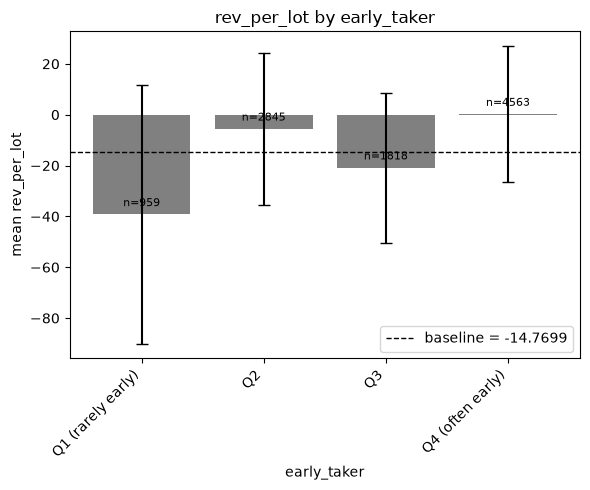

Flip point: lowest bucket with mean rev_per_lot > 0 is 'Q4 (often early)'

early_taker quartile sweep — RESTRICTED to current trade also has_TP (n=11301)


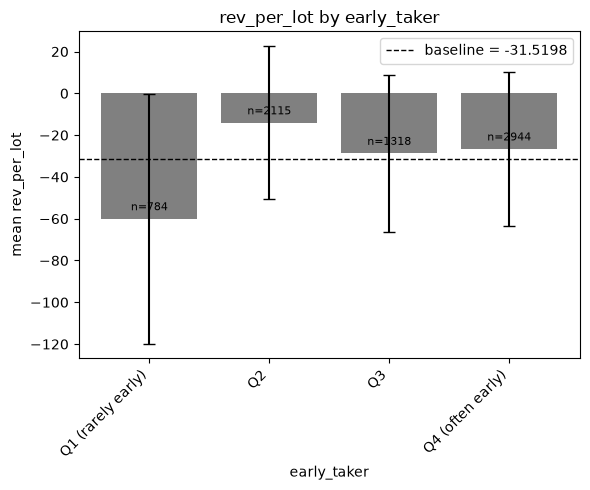

Flip point: no flip

Does the signal hold on the SL/TP-setting subpopulation?
Full population top bucket: Q4 (often early) (mean=0.1816, n=4563)
has_TP-restricted top bucket: Q2 (mean=-14.0354, n=2115)

PARTIALLY — top bucket differs, check both tables above — the signal does not clearly hold on both the full population and the SL/TP-setting subpopulation.


In [45]:
# NOTE: partial-population bias — only defined for trades where the trader set a TP.

work = discovery_df.sort_values(["traderId", "campaignId", "trade_seq_in_campaign"]).copy()

tp_coverage_pct = 100 * work["has_TP"].mean()
print(f"Coverage: {tp_coverage_pct:.1f}% of trades in discovery_df set a TP "
      f"(has_TP==True, n={int(work['has_TP'].sum())} of {len(work)}). "
      f"This bias only applies to that subpopulation.\n")

# --- tp_distance_own: expanding mean (shifted), over PRIOR TP-set trades only ---
work["tp_distance_raw"] = np.where(work["has_TP"], (work["tpPrice"] - work["openPrice"]).abs(), np.nan)
work["tp_distance_own"] = work.groupby(["traderId", "campaignId"])["tp_distance_raw"].transform(
    lambda s: s.shift(1).expanding().mean()
)

# --- early_taker: lagged trait — historical rate of closing winners well short of own TP ---
# "well short" = actual exit distance < 75% of that trade's own intended TP distance
actual_distance = (work["closePrice"] - work["openPrice"]).abs()
is_winner = work["netProfit"] > 0
work["is_early_trade"] = np.where(
    work["has_TP"] & is_winner,
    (actual_distance < 0.75 * work["tp_distance_raw"]).astype(float),
    np.nan,
)
work["early_taker"] = work.groupby(["traderId", "campaignId"])["is_early_trade"].transform(
    lambda s: s.shift(1).expanding().mean()
)

early_taker_coverage_pct = 100 * work["early_taker"].notna().mean()
print(f"early_taker trait coverage: {early_taker_coverage_pct:.1f}% of ALL discovery_df trades "
      f"have a defined trait (n={int(work['early_taker'].notna().sum())} of {len(work)}) — "
      f"i.e. the trader has at least one prior winning TP-set trade this campaign to learn from.\n")

discovery_df["tp_distance_own"] = work["tp_distance_own"]
discovery_df["early_taker"] = work["early_taker"]

# --- bucket by early_taker quartile, score vs rev_per_lot ---
et_df = discovery_df.dropna(subset=["early_taker"]).copy()
et_baseline = et_df["rev_per_lot"].mean()
print(f"{'=' * 70}\nearly_taker quartile sweep — FULL population where the trait is defined "
      f"(baseline={et_baseline:.4f}, n={len(et_df)})\n{'=' * 70}")
full_result = sweep(
    et_df, "early_taker", bins=[0, .25, .5, .75, 1.0], baseline_rev_per_lot=et_baseline,
    labels=["Q1 (rarely early)", "Q2", "Q3", "Q4 (often early)"],
)

# --- does the signal hold when ALSO restricted to the SL/TP-setting subpopulation? ---
et_tp_df = et_df[et_df["has_TP"]].copy()
et_tp_n = len(et_tp_df)
print(f"\n{'=' * 70}\nearly_taker quartile sweep — RESTRICTED to current trade also has_TP "
      f"(n={et_tp_n})\n{'=' * 70}")

tp_result = None
if et_tp_n >= 100:
    tp_baseline = et_tp_df["rev_per_lot"].mean()
    tp_result = sweep(
        et_tp_df, "early_taker", bins=[0, .25, .5, .75, 1.0], baseline_rev_per_lot=tp_baseline,
        labels=["Q1 (rarely early)", "Q2", "Q3", "Q4 (often early)"],
    )
else:
    print(f"Too few trades (n={et_tp_n}) in the has_TP-restricted subpopulation to sweep reliably.")

print(f"\n{'=' * 70}\nDoes the signal hold on the SL/TP-setting subpopulation?\n{'=' * 70}")
full_top = full_result.loc[full_result["mean_rev_per_lot"].idxmax()]
print(f"Full population top bucket: {full_top['bucket']} "
      f"(mean={full_top['mean_rev_per_lot']:.4f}, n={int(full_top['n'])})")
if tp_result is not None:
    tp_top = tp_result.loc[tp_result["mean_rev_per_lot"].idxmax()]
    print(f"has_TP-restricted top bucket: {tp_top['bucket']} "
          f"(mean={tp_top['mean_rev_per_lot']:.4f}, n={int(tp_top['n'])})")
    same_bucket = full_top["bucket"] == tp_top["bucket"]
    print(f"\n{'YES — consistent' if same_bucket else 'PARTIALLY — top bucket differs, check both tables above'} "
          f"— the signal {'holds' if same_bucket else 'does not clearly hold'} on both the full population "
          f"and the SL/TP-setting subpopulation.")
else:
    print("\nCannot check whether the signal holds on the SL/TP-setting subpopulation — too few trades there.")


# FEATURE ENGINEERING BY DEVANSHI

In [46]:
# trades_sorted was referenced below but never defined in this notebook -- it
# was originally built in the now-deleted notebooks/profiling.ipynb, grouped by
# accountId (which recycles across campaigns -- exactly the problem traderId was
# introduced to fix). Rebuilt here on traderId/campaignId instead, matching this
# notebook's established convention everywhere else.
trades_sorted = trades_campaign_features_df[
    trades_campaign_features_df["traderId"].notna()
].sort_values(["traderId", "campaignId", "trade_seq_in_campaign"]).copy()

print(f"trades_sorted: {len(trades_sorted)} rows, "
      f"{trades_sorted['traderId'].nunique()} traders, "
      f"{trades_sorted['campaignId'].nunique()} campaigns")

trades_sorted: 46376 rows, 3550 traders, 34 campaigns


In [47]:
baseline_rev_per_lot = (trades_sorted["reverseProfit"] / trades_sorted["amount"]).mean()
print("Baseline (fade every trade blindly):", baseline_rev_per_lot)

Baseline (fade every trade blindly): -5.244591989412701


In [48]:
trades_sorted["rev_per_lot"] = trades_sorted["reverseProfit"] / trades_sorted["amount"]

In [49]:
campaign_ids = sorted(trades_sorted["campaignId"].astype(int).unique())
n_campaigns = len(campaign_ids)
split_point = int(n_campaigns * 0.7)

discovery_campaigns = campaign_ids[:split_point]
confirmation_campaigns = campaign_ids[split_point:]

print(f"Discovery: {len(discovery_campaigns)} campaigns, campaigns {discovery_campaigns[0]}-{discovery_campaigns[-1]}")
print(f"Confirmation: {len(confirmation_campaigns)} campaigns, campaigns {confirmation_campaigns[0]}-{confirmation_campaigns[-1]}")

trades_sorted["campaignId_int"] = trades_sorted["campaignId"].astype(int)
discovery = trades_sorted[trades_sorted["campaignId_int"].isin(discovery_campaigns)].copy()
confirmation = trades_sorted[trades_sorted["campaignId_int"].isin(confirmation_campaigns)].copy()

print(f"\nDiscovery: {len(discovery)} trades")
print(f"Confirmation: {len(confirmation)} trades")

Discovery: 23 campaigns, campaigns 33-55
Confirmation: 11 campaigns, campaigns 56-66

Discovery: 28878 trades
Confirmation: 17498 trades


In [ ]:
import numpy as np

def run_permutation_test(df, n_permutations=1000, seed=42):
    rng = np.random.default_rng(seed)
    
    # observed: real avg rev_per_lot for "deep drawdown + flagged" cell
    real_cell = df[(df["dd_bucket"] == "Deep drawdown") & (df["flagged"] == True)]
    observed = real_cell["rev_per_lot"].mean()
    
    null_results = []
    for i in range(n_permutations):
        shuffled = df.copy()
        # shuffle the 'flagged' label WITHIN each trader's own trades only
        shuffled["flagged"] = shuffled.groupby("traderId")["flagged"].transform(
            lambda x: rng.permutation(x.values)
        )
        shuffled_cell = shuffled[(shuffled["dd_bucket"] == "Deep drawdown") & (shuffled["flagged"] == True)]
        if len(shuffled_cell) > 0:
            null_results.append(shuffled_cell["rev_per_lot"].mean())
    
    null_results = np.array(null_results)
    p_value = (null_results >= observed).mean()
    
    print(f"Observed: {observed:.2f}")
    print(f"Null mean (shuffled): {null_results.mean():.2f}")
    print(f"P-value: {p_value:.4f}")
    return observed, null_results, p_value

print("=== DISCOVERY ===")
run_permutation_test(discovery)

=== DISCOVERY ===


KeyError: 'dd_bucket'

: 

In [ ]:
def redundancy_ratio(df):
    dd_alone = df[df["dd_bucket"] == "Deep drawdown"]["rev_per_lot"].mean()
    flag_alone = df[df["flagged"] == True]["rev_per_lot"].mean()
    both = df[(df["dd_bucket"] == "Deep drawdown") & (df["flagged"] == True)]["rev_per_lot"].mean()
    
    best_single = max(dd_alone, flag_alone)
    ratio = both / best_single if best_single != 0 else float('nan')
    
    print(f"Drawdown alone: {dd_alone:.2f}")
    print(f"Flag alone: {flag_alone:.2f}")
    print(f"Combined: {both:.2f}")
    print(f"Ratio (combined / best single): {ratio:.2f}")
    print("Verdict:", "COMPLEMENTARY" if ratio > 1.3 else "REDUNDANT")
    print()

print("=== DISCOVERY ===")
redundancy_ratio(discovery)

print("=== CONFIRMATION ===")
redundancy_ratio(confirmation)

In [ ]:
def build_interaction_grid(df, dd_bins, dd_labels):
    df = df.copy()
    df["dd_bucket"] = pd.cut(df["current_drawdown"], bins=dd_bins, labels=dd_labels)
    df["flag_label"] = df["flagged"].map({True: "No-SL, long+large", False: "Not flagged"})
    
    grid = df.groupby(["dd_bucket", "flag_label"], observed=True).agg(
        avg_rev_per_lot=("rev_per_lot", "mean"),
        n_trades=("rev_per_lot", "count")
    ).reset_index()
    return grid

dd_bins = [-np.inf, -150, -50, 0]
dd_labels = ["Deep drawdown", "Mid drawdown", "Shallow/no drawdown"]

print("=== DISCOVERY ===")
discovery_grid = build_interaction_grid(discovery, dd_bins, dd_labels)
print(discovery_grid.sort_values("avg_rev_per_lot", ascending=False))

print("\n=== CONFIRMATION ===")
confirmation_grid = build_interaction_grid(confirmation, dd_bins, dd_labels)
print(confirmation_grid.sort_values("avg_rev_per_lot", ascending=False))

In [ ]:
no_sl = trades_sorted[~trades_sorted["has_SL"]].copy()
no_sl["is_catastrophic"] = no_sl["netProfit"] < -300

# duration sweep
dur_bins = [0, 60, 180, 300, 600, 1200, 3600, np.inf]
dur_labels = ["<1min", "1-3min", "3-5min", "5-10min", "10-20min", "20-60min", "60min+"]
no_sl["dur_bucket"] = pd.cut(no_sl["durationSec"], bins=dur_bins, labels=dur_labels)

print("=== Catastrophic rate by duration bucket ===")
print(no_sl.groupby("dur_bucket", observed=True)["is_catastrophic"].agg(["mean", "count"]))

# size sweep
size_bins = no_sl["amount"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1.0]).values
no_sl["size_bucket"] = pd.qcut(no_sl["amount"], q=5, labels=["Q1 (smallest)", "Q2", "Q3", "Q4", "Q5 (largest)"])

print("\n=== Catastrophic rate by size quintile ===")
print(no_sl.groupby("size_bucket", observed=True)["is_catastrophic"].agg(["mean", "count"]))

In [ ]:
no_sl["duration_pctile"] = no_sl["durationSec"].rank(pct=True)
no_sl["size_pctile"] = no_sl["amount"].rank(pct=True)

# simple additive risk score: average of the two percentile ranks (0 to 1 scale)
no_sl["risk_score"] = (no_sl["duration_pctile"] + no_sl["size_pctile"]) / 2

# check: does risk_score actually separate catastrophic from non-catastrophic?
print(no_sl.groupby(pd.qcut(no_sl["risk_score"], q=5))["is_catastrophic"].mean())

In [ ]:
no_sl["campaignId_int"] = no_sl["campaignId"].astype(int)
disc_nosl = no_sl[no_sl["campaignId_int"].isin(discovery_campaigns)]
conf_nosl = no_sl[no_sl["campaignId_int"].isin(confirmation_campaigns)]

for name, d in [("Discovery", disc_nosl), ("Confirmation", conf_nosl)]:
    print(f"\n=== {name} ===")
    print(d.groupby(pd.qcut(d["risk_score"], q=5, duplicates="drop"))["is_catastrophic"].agg(["mean", "count"]))

In [ ]:
for name, d in [("Discovery", disc_nosl), ("Confirmation", conf_nosl)]:
    print(f"\n=== {name}: rev_per_lot by risk score quintile ===")
    print(d.groupby(pd.qcut(d["risk_score"], q=5, duplicates="drop"))["rev_per_lot"].agg(["mean", "count"]))

In [ ]:
def run_permutation_test_score(df, top_quintile_threshold, n_permutations=1000, seed=42):
    rng = np.random.default_rng(seed)
    real_top = df[df["risk_score"] >= top_quintile_threshold]
    observed = real_top["rev_per_lot"].mean()
    
    null_results = []
    for i in range(n_permutations):
        shuffled = df.copy()
        shuffled["risk_score"] = shuffled.groupby("traderId")["risk_score"].transform(
            lambda x: rng.permutation(x.values)
        )
        shuffled_top = shuffled[shuffled["risk_score"] >= top_quintile_threshold]
        if len(shuffled_top) > 0:
            null_results.append(shuffled_top["rev_per_lot"].mean())
    
    null_results = np.array(null_results)
    p_value = (null_results >= observed).mean()
    print(f"Observed: {observed:.2f}, Null mean: {null_results.mean():.2f}, p={p_value:.4f}")

threshold = disc_nosl["risk_score"].quantile(0.8)
run_permutation_test_score(disc_nosl, threshold)